In [2]:
import sys; print(sys.executable)

/Users/ginniema/Desktop/Research/Active Inference (Candes)/Key examples/BRCA/.venv/bin/python


In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from scipy.stats import norm, bernoulli
import json
import warnings; warnings.simplefilter('ignore')
from tqdm import tqdm
from plotting_utils import plot_naive_coverage, plot_eff_sample_size, plot_coverage, plot_intervals
from stance_utils import odds_ratio_ci, opt_mean_tuning
import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
# load in appropriate packages
import seaborn as sns
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import norm, bernoulli, beta, expon
import matplotlib.patheffects as pe
import cvxpy as cp
from IPython.display import clear_output
import time
from patsy import dmatrix # For generating spline basis
from matplotlib.lines import Line2D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# same original split, using this to get mu0, mu1 initial estimates from the data
#master_df = pd.read_csv("master_df.csv")
master_df = pd.read_csv("master_df_withpred.csv")
status = ["TNBC", "nonTNBC"]
master_df["strat"] = master_df["race"] + "_" + master_df["is_tnbc"].map({True: "TNBC", False: "nonTNBC"})
master_df
np.random.seed(614)
train_df, test_df = train_test_split(master_df, test_size = 0.80,
                               stratify = master_df["strat"],
                               random_state = 0)


In [28]:
#mu0, mu1 estimates from train_df
contingency_train = pd.crosstab(train_df['race'], train_df['is_tnbc'])
contingency_train.columns = ['Non-TNBC', 'TNBC']
n1_train, n0_train = contingency_train.sum(axis=1) #number of B (gp 1) and number of W (gp0)
mu1_train = contingency_train.iloc[0,1] / n1_train
mu0_train = contingency_train.iloc[1,1] / n0_train

,Non-TNBC,TNBC,Total
Race,,,
B,103,41,144
W,510,85,595
Total,613,126,739


,Non-TNBC,TNBC,Total
Race,,,
B,136,8,144
W,575,20,595
Total,711,28,739


,N,N_TNBC,TNBC rate,CNN acc,Majority-vote acc,Bernoulli baseline acc,AUC
Group,,,,,,,
B,144,41,28.5%,71.5%,71.5%,59.3%,0.643
W,595,85,14.3%,85.0%,85.7%,75.5%,0.735
Overall,739,126,17.1%,82.4%,82.9%,71.7%,0.714


,precision,recall,f1-score,support
Class,,,,
Non-TNBC,0.84,0.97,0.90,613
TNBC,0.43,0.10,0.16,126
Macro avg,0.63,0.53,0.53,739
Weighted avg,0.77,0.82,0.77,739


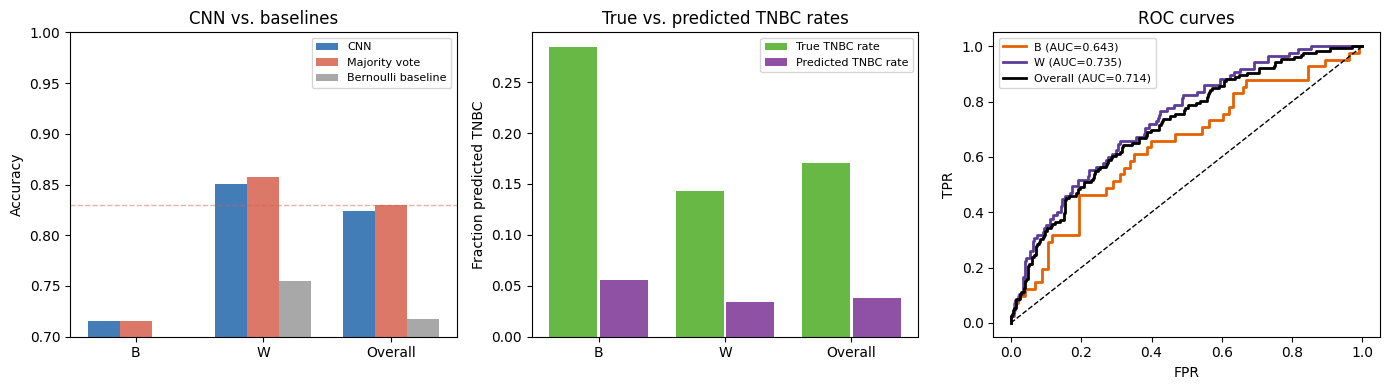

In [6]:

# ── Diagnostics: CNN predictions vs. majority-vote / Bernoulli baselines ──────
from IPython.display import display, HTML
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

diag_df = master_df.copy()

# shared table style
_tbl_styles = [
    {"selector": "thead th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-weight", "bold"), ("text-align", "center"),
               ("padding", "8px 14px")]},
    {"selector": "tbody td",
     "props": [("text-align", "center"), ("padding", "6px 14px")]},
    {"selector": "tbody tr:nth-child(even)",
     "props": [("background-color", "#f2f2f2")]},
    {"selector": "tbody tr:last-child td",
     "props": [("font-weight", "bold"), ("border-top", "2px solid #2c3e50")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"), ("font-size", "13px"),
               ("font-family", "sans-serif"), ("margin", "8px 0")]},
]

def _highlight_total(row):
    if row.name == "Total":
        return ["background-color: #dce6f0; font-weight: bold"] * len(row)
    return [""] * len(row)

# ── Table A: true labels ──────────────────────────────────────────────────────
ct_true = pd.crosstab(diag_df['race'], diag_df['is_tnbc'].map({False: 'Non-TNBC', True: 'TNBC'}),
                      margins=True, margins_name='Total')
ct_true.columns.name = None
ct_true.index.name   = "Race"

display(HTML("<b>Table A — True labels (race × TNBC status)</b>"))
display(ct_true.style.set_table_styles(_tbl_styles).apply(_highlight_total, axis=1))

# ── Table B: predicted labels ─────────────────────────────────────────────────
ct_pred = pd.crosstab(diag_df['race'],
                      diag_df['predicted_label'].map({0.0: 'Non-TNBC', 1.0: 'TNBC'}),
                      margins=True, margins_name='Total')
ct_pred.columns.name = None
ct_pred.index.name   = "Race"

display(HTML("<b>Table B — CNN predicted labels (race × predicted TNBC status)</b>"))
display(ct_pred.style.set_table_styles(_tbl_styles).apply(_highlight_total, axis=1))

# ── 2. Group-level stats ──────────────────────────────────────────────────────
groups = {}
for race, gdf in diag_df.groupby('race'):
    n        = len(gdf)
    n_tnbc   = gdf['is_tnbc'].sum()
    p_tnbc   = n_tnbc / n
    acc_cnn  = gdf['is_correct'].mean()
    acc_maj  = 1 - p_tnbc
    acc_bern = (1 - p_tnbc)**2 + p_tnbc**2
    auc      = roc_auc_score(gdf['is_tnbc'].astype(int), gdf['predicted_probability'])
    groups[race] = dict(N=n, N_TNBC=int(n_tnbc),
                        **{"TNBC rate": p_tnbc, "CNN acc": acc_cnn,
                           "Majority-vote acc": acc_maj,
                           "Bernoulli baseline acc": acc_bern, "AUC": auc})

n_all        = len(diag_df)
p_all        = diag_df['is_tnbc'].mean()
acc_cnn_all  = diag_df['is_correct'].mean()
acc_maj_all  = 1 - p_all
acc_bern_all = (1 - p_all)**2 + p_all**2
auc_all      = roc_auc_score(diag_df['is_tnbc'].astype(int), diag_df['predicted_probability'])
groups['Overall'] = dict(N=n_all, N_TNBC=int(diag_df['is_tnbc'].sum()),
                         **{"TNBC rate": p_all, "CNN acc": acc_cnn_all,
                            "Majority-vote acc": acc_maj_all,
                            "Bernoulli baseline acc": acc_bern_all, "AUC": auc_all})

summary = pd.DataFrame(groups).T
summary.index.name = "Group"

def _highlight_cnn_vs_maj(val, other):
    """Red if CNN acc < majority-vote acc, green if higher."""
    if val < other:
        return "color: #c0392b; font-weight: bold"
    elif val > other:
        return "color: #27ae60; font-weight: bold"
    return ""

# ── Table C: accuracy comparison ─────────────────────────────────────────────
display(HTML("<b>Table C — Accuracy comparison</b>"))

_c_styles = [
    {"selector": "thead th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-weight", "bold"), ("text-align", "center"),
               ("padding", "8px 14px")]},
    {"selector": "tbody td",
     "props": [("text-align", "center"), ("padding", "6px 14px")]},
    {"selector": "tbody tr:nth-child(even)",
     "props": [("background-color", "#f2f2f2")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"), ("font-size", "13px"),
               ("font-family", "sans-serif"), ("margin", "8px 0")]},
]

tbl_c = (summary[["N", "N_TNBC", "TNBC rate", "CNN acc",
                   "Majority-vote acc", "Bernoulli baseline acc", "AUC"]]
         .style
         .set_table_styles(_c_styles)
         .format({"N": "{:.0f}", "N_TNBC": "{:.0f}",
                  "TNBC rate": "{:.1%}", "CNN acc": "{:.1%}",
                  "Majority-vote acc": "{:.1%}", "Bernoulli baseline acc": "{:.1%}",
                  "AUC": "{:.3f}"})
         .apply(lambda col: [
             _highlight_cnn_vs_maj(col[g], summary.loc[g, "Majority-vote acc"])
             if col.name == "CNN acc" else "" for g in col.index
         ], axis=0))
display(tbl_c)

# ── Table D: classification report ───────────────────────────────────────────
display(HTML("<b>Table D — Classification report (full dataset)</b>"))
cr_dict = classification_report(diag_df['is_tnbc'].astype(int),
                                 diag_df['predicted_label'].astype(int),
                                 target_names=['Non-TNBC', 'TNBC'],
                                 output_dict=True)
cr_df = (pd.DataFrame(cr_dict).T
           .drop(index=["accuracy"], errors="ignore")
           .rename(index={"macro avg": "Macro avg", "weighted avg": "Weighted avg"}))
cr_df.index.name = "Class"

def _bar_gradient(s, color="#4393c3"):
    return [f"background: linear-gradient(90deg, {color} {v*100:.0f}%, transparent {v*100:.0f}%); color: #1a1a1a"
            if 0 < v <= 1 else "" for v in s]

tbl_d = (cr_df.style
         .set_table_styles(_c_styles)
         .format({"precision": "{:.2f}", "recall": "{:.2f}",
                  "f1-score": "{:.2f}", "support": "{:.0f}"})
         .apply(_bar_gradient, subset=["precision", "recall", "f1-score"]))
display(tbl_d)

# ── 4. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

races   = ['B', 'W']
metrics = ['CNN acc', 'Majority-vote acc', 'Bernoulli baseline acc']
colors  = ['#2166ac', '#d6604d', '#999999']
labels  = ['CNN', 'Majority vote', 'Bernoulli baseline']

# (a) Accuracy bar chart by group
x     = np.arange(len(races) + 1)
width = 0.25
for i, (met, col, lbl) in enumerate(zip(metrics, colors, labels)):
    vals = [summary.loc[r, met] for r in races] + [summary.loc['Overall', met]]
    axes[0].bar(x + i*width, vals, width, label=lbl, color=col, alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(races + ['Overall'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN vs. baselines')
axes[0].set_ylim(0.7, 1.0)
axes[0].legend(fontsize=8)
axes[0].axhline(acc_maj_all, color='#d6604d', lw=1, ls='--', alpha=0.5)

# (b) Predicted vs. true TNBC proportions
true_rates = [groups[r]['TNBC rate'] for r in races] + [p_all]
pred_rates = [diag_df[diag_df['race']==r]['predicted_label'].mean() for r in races] + [diag_df['predicted_label'].mean()]
x2 = np.arange(len(races) + 1)
axes[1].bar(x2 - 0.2, true_rates,  0.38, label='True TNBC rate',      color='#4dac26', alpha=0.85)
axes[1].bar(x2 + 0.2, pred_rates,  0.38, label='Predicted TNBC rate', color='#7b3294', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(races + ['Overall'])
axes[1].set_ylabel('Fraction predicted TNBC')
axes[1].set_title('True vs. predicted TNBC rates')
axes[1].legend(fontsize=8)

# (c) ROC curve by group + overall
from sklearn.metrics import roc_curve
roc_colors = {'B': '#e66101', 'W': '#5e3c99', 'Overall': 'black'}
for race in races + ['Overall']:
    sub = diag_df if race == 'Overall' else diag_df[diag_df['race'] == race]
    fpr, tpr, _ = roc_curve(sub['is_tnbc'].astype(int), sub['predicted_probability'])
    auc_val = groups[race]['AUC']
    axes[2].plot(fpr, tpr, color=roc_colors[race],
                 label=f"{race} (AUC={auc_val:.3f})", lw=2)
axes[2].plot([0,1],[0,1],'k--',lw=1)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC curves')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


,Non-TNBC,TNBC,Total
Race,,,
B,82,33,115
W,409,68,477
Total,491,101,592


,Non-TNBC,TNBC,Total
Race,,,
B,110,5,115
W,464,13,477
Total,574,18,592


,N,N_TNBC,TNBC rate (train),TNBC rate (test),CNN acc,Majority-vote acc,Bernoulli baseline acc,AUC
Group,,,,,,,,
B,115,33,27.6%,28.7%,72.2%,71.3%,60.0%,0.616
W,477,68,14.4%,14.3%,85.1%,85.7%,75.3%,0.719
Overall,592,101,17.0%,17.1%,82.6%,82.9%,71.8%,0.695


,precision,recall,f1-score,support
Class,,,,
Non-TNBC,0.84,0.98,0.90,491
TNBC,0.44,0.08,0.13,101
Macro avg,0.64,0.53,0.52,592
Weighted avg,0.77,0.83,0.77,592


,Pred Non-TNBC,Pred TNBC
,,
True Non-TNBC,481,10
True TNBC,93,8


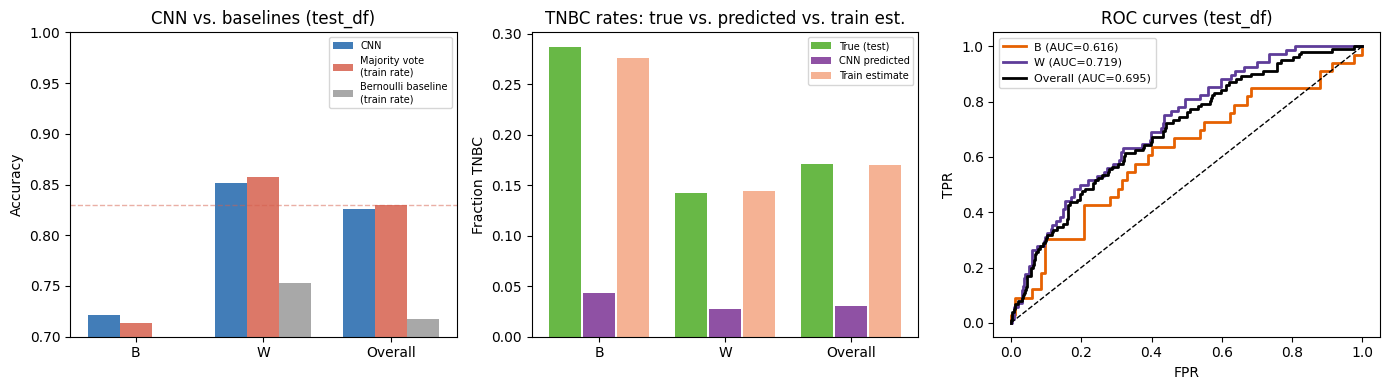

In [11]:

# ── Full diagnostics: baselines from train_df, predictions on test_df ─────────
# Majority-vote and Bernoulli rules calibrated on train_df labels only.
# CNN accuracy / AUC / contingency tables all use test_df.

from IPython.display import display, HTML
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

eval_df = test_df.copy()

# ── Shared table style ────────────────────────────────────────────────────────
_styles = [
    {"selector": "thead th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-weight", "bold"), ("text-align", "center"),
               ("padding", "8px 14px")]},
    {"selector": "tbody td",
     "props": [("text-align", "center"), ("padding", "6px 14px")]},
    {"selector": "tbody tr:nth-child(even)",
     "props": [("background-color", "#f2f2f2")]},
    {"selector": "tbody tr:last-child td",
     "props": [("font-weight", "bold"), ("border-top", "2px solid #2c3e50")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"), ("font-size", "13px"),
               ("font-family", "sans-serif"), ("margin", "8px 0")]},
]

def _highlight_total(row):
    if row.name == "Total":
        return ["background-color: #dce6f0; font-weight: bold"] * len(row)
    return [""] * len(row)

# ── Table A: true labels on test_df ──────────────────────────────────────────
ct_true = pd.crosstab(eval_df['race'],
                      eval_df['is_tnbc'].map({False: 'Non-TNBC', True: 'TNBC'}),
                      margins=True, margins_name='Total')
ct_true.columns.name = None
ct_true.index.name   = "Race"

display(HTML("<b>Table A — True labels on test_df (race × TNBC status)</b>"))
display(ct_true.style.set_table_styles(_styles).apply(_highlight_total, axis=1))

# ── Table B: CNN predicted labels on test_df ──────────────────────────────────
ct_pred = pd.crosstab(eval_df['race'],
                      eval_df['predicted_label'].map({0.0: 'Non-TNBC', 1.0: 'TNBC'}),
                      margins=True, margins_name='Total')
ct_pred.columns.name = None
ct_pred.index.name   = "Race"

display(HTML("<b>Table B — CNN predicted labels on test_df (race × predicted TNBC status)</b>"))
display(ct_pred.style.set_table_styles(_styles).apply(_highlight_total, axis=1))

# ── Step 1: estimate p from train_df ─────────────────────────────────────────
train_p = {race: gdf['is_tnbc'].mean() for race, gdf in train_df.groupby('race')}
train_p['Overall'] = train_df['is_tnbc'].mean()

# ── Step 2: per-group stats ───────────────────────────────────────────────────
groups = {}
for race in ['B', 'W', 'Overall']:
    sub      = eval_df if race == 'Overall' else eval_df[eval_df['race'] == race]
    p_train  = train_p[race]
    n        = len(sub)
    n_tnbc   = int(sub['is_tnbc'].sum())
    acc_cnn  = sub['is_correct'].mean()
    acc_maj  = (sub['is_tnbc'] == (p_train >= 0.5)).mean()   # rule from train
    acc_bern = (1 - p_train)**2 + p_train**2                 # E[acc] from train p
    auc      = roc_auc_score(sub['is_tnbc'].astype(int), sub['predicted_probability'])
    groups[race] = dict(N=n, N_TNBC=n_tnbc,
                        **{"TNBC rate (train)": p_train,
                           "TNBC rate (test)":  sub['is_tnbc'].mean(),
                           "CNN acc": acc_cnn,
                           "Majority-vote acc": acc_maj,
                           "Bernoulli baseline acc": acc_bern,
                           "AUC": auc})

summary = pd.DataFrame(groups).T
summary.index.name = "Group"

# ── Table C: accuracy comparison ─────────────────────────────────────────────
def _color_cnn(col):
    if col.name != "CNN acc":
        return [""] * len(col)
    return [
        "color: #c0392b; font-weight: bold" if col[g] < summary.loc[g, "Majority-vote acc"]
        else ("color: #27ae60; font-weight: bold" if col[g] > summary.loc[g, "Majority-vote acc"]
              else "")
        for g in col.index
    ]

display(HTML(
    "<b>Table C — Accuracy comparison</b><br>"
    "<small style='color:#555'>Baselines use empirical rates from "
    "<code>train_df</code>; everything evaluated on <code>test_df</code>.</small>"
))
display(
    summary[["N", "N_TNBC", "TNBC rate (train)", "TNBC rate (test)",
             "CNN acc", "Majority-vote acc", "Bernoulli baseline acc", "AUC"]]
    .style.set_table_styles(_styles)
    .format({"N": "{:.0f}", "N_TNBC": "{:.0f}",
             "TNBC rate (train)": "{:.1%}", "TNBC rate (test)": "{:.1%}",
             "CNN acc": "{:.1%}", "Majority-vote acc": "{:.1%}",
             "Bernoulli baseline acc": "{:.1%}", "AUC": "{:.3f}"})
    .apply(_color_cnn, axis=0)
)

# ── Table D: classification report on test_df ─────────────────────────────────
display(HTML("<b>Table D — Classification report (test_df)</b>"))
cr_dict = classification_report(eval_df['is_tnbc'].astype(int),
                                eval_df['predicted_label'].astype(int),
                                target_names=['Non-TNBC', 'TNBC'],
                                output_dict=True)
cr_df = (pd.DataFrame(cr_dict).T
           .drop(index=["accuracy"], errors="ignore")
           .rename(index={"macro avg": "Macro avg", "weighted avg": "Weighted avg"}))
cr_df.index.name = "Class"

def _bar_gradient(s, color="#4393c3"):
    return [f"background: linear-gradient(90deg, {color} {v*100:.0f}%, transparent {v*100:.0f}%); color: #1a1a1a"
            if 0 < v <= 1 else "" for v in s]

display(
    cr_df.style.set_table_styles(_styles)
    .format({"precision": "{:.2f}", "recall": "{:.2f}",
             "f1-score": "{:.2f}", "support": "{:.0f}"})
    .apply(_bar_gradient, subset=["precision", "recall", "f1-score"])
)

# ── Table E: confusion matrix ────────────────────────────────────────────────
display(HTML("<b>Table E — Confusion matrix (test_df)</b>"))
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(eval_df['is_tnbc'].astype(int),
                      eval_df['predicted_label'].astype(int))
cm_df = pd.DataFrame(cm,
                     index=pd.Index(['True Non-TNBC', 'True TNBC'], name=''),
                     columns=pd.Index(['Pred Non-TNBC', 'Pred TNBC'], name=''))

_cm_styles = [
    {"selector": "thead th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-weight", "bold"), ("text-align", "center"),
               ("padding", "10px 20px"), ("font-size", "13px")]},
    {"selector": "th.row_heading",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-weight", "bold"), ("text-align", "right"),
               ("padding", "10px 16px"), ("font-size", "13px")]},
    {"selector": "tbody td",
     "props": [("text-align", "center"), ("padding", "12px 24px"),
               ("font-size", "15px"), ("font-weight", "bold")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"), ("font-family", "sans-serif"),
               ("margin", "8px 0")]},
]

import matplotlib.colors as mcolors

def _heatmap_cm(df):
    vmin, vmax = 0, cm.max()
    cmap = plt.cm.Blues
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = df.iloc[i, j]
            norm_val = (val - vmin) / (vmax - vmin) if vmax > vmin else 0
            rgba = cmap(norm_val)
            hex_bg = mcolors.to_hex(rgba)
            # use white text on dark cells, dark text on light cells
            font_color = '#ffffff' if norm_val > 0.55 else '#1a1a1a'
            styles.iloc[i, j] = f'background-color: {hex_bg}; color: {font_color}'
    return styles

display(cm_df.style.set_table_styles(_cm_styles).apply(_heatmap_cm, axis=None))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
races   = ['B', 'W']
metrics = ['CNN acc', 'Majority-vote acc', 'Bernoulli baseline acc']
colors  = ['#2166ac', '#d6604d', '#999999']
labels  = ['CNN', 'Majority vote\n(train rate)', 'Bernoulli baseline\n(train rate)']

# (a) Accuracy bar chart by group
x, width = np.arange(len(races) + 1), 0.25
for i, (met, col, lbl) in enumerate(zip(metrics, colors, labels)):
    vals = [summary.loc[r, met] for r in races] + [summary.loc['Overall', met]]
    axes[0].bar(x + i*width, vals, width, label=lbl, color=col, alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(races + ['Overall'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN vs. baselines (test_df)')
axes[0].set_ylim(0.7, 1.0)
axes[0].legend(fontsize=7)
axes[0].axhline(summary.loc['Overall', 'Majority-vote acc'],
                color='#d6604d', lw=1, ls='--', alpha=0.5)

# (b) Predicted vs. true TNBC rates
true_rates = [groups[r]['TNBC rate (test)'] for r in races] + [groups['Overall']['TNBC rate (test)']]
pred_rates = [eval_df[eval_df['race']==r]['predicted_label'].mean() for r in races] + [eval_df['predicted_label'].mean()]
train_rates_list = [train_p[r] for r in races] + [train_p['Overall']]
x2 = np.arange(len(races) + 1)
axes[1].bar(x2 - 0.27, true_rates,       0.25, label='True (test)',       color='#4dac26', alpha=0.85)
axes[1].bar(x2,         pred_rates,       0.25, label='CNN predicted',     color='#7b3294', alpha=0.85)
axes[1].bar(x2 + 0.27, train_rates_list, 0.25, label='Train estimate',    color='#f4a582', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(races + ['Overall'])
axes[1].set_ylabel('Fraction TNBC')
axes[1].set_title('TNBC rates: true vs. predicted vs. train est.')
axes[1].legend(fontsize=7)

# (c) ROC curves by group + overall
roc_colors = {'B': '#e66101', 'W': '#5e3c99', 'Overall': 'black'}
for race in races + ['Overall']:
    sub = eval_df if race == 'Overall' else eval_df[eval_df['race'] == race]
    fpr, tpr, _ = roc_curve(sub['is_tnbc'].astype(int), sub['predicted_probability'])
    axes[2].plot(fpr, tpr, color=roc_colors[race],
                 label=f"{race} (AUC={groups[race]['AUC']:.3f})", lw=2)
axes[2].plot([0,1],[0,1],'k--',lw=1)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC curves (test_df)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


Table,PNG,CSV
Table A — True labels (test_df),⬇ PNG,⬇ CSV
Table B — CNN predicted labels (test_df),⬇ PNG,⬇ CSV
Table C — Accuracy comparison,⬇ PNG,"<a href=""data:text/csv;base64,R3JvdXAsTixOX1ROQkMsVE5CQyByYXRlICh0cmFpbiksVE5CQyByYXRlICh0ZXN0KSxDTk4gYWNjLE1ham9yaXR5LXZvdGUgYWNjLEJlcm5vdWxsaSBiYXNlbGluZSBhY2MsQVVDCkIsMTE1LjAsMzMuMCwwLjI3NTg2MjA2ODk2NTUxNzI0LDAuMjg2OTU2NTIxNzM5MTMwNDQsMC43MjE3MzkxMzA0MzQ3ODI3LDAuNzEzMDQzNDc4MjYwODY5NiwwLjYwMDQ3NTYyNDI1NjgzNzIsMC42MTY0MDc5ODIyNjE2NDA4ClcsNDc3LjAsNjguMCwwLjE0NDA2Nzc5NjYxMDE2OTUsMC4xNDI1NTc2NTE5OTE2MTQyNCwwLjg1MTE1MzAzOTgzMjI4NTEsMC44NTc0NDIzNDgwMDgzODU3LDAuNzUzMzc1NDY2ODE5ODc5MywwLjcxODcxODUzODc2MDI0NzMKT3ZlcmFsbCw1OTIuMCwxMDEuMCwwLjE3MDA2ODAyNzIxMDg4NDM1LDAuMTcwNjA4MTA4MTA4MTA4MTEsMC44MjYwMTM1MTM1MTM1MTM1LDAuODI5MzkxODkxODkxODkxOSwwLjcxNzcxMDIxMzMzNzAzNTYsMC42OTQ4NDM4MjI0Njc3ODY0Cg=="" download=""C_accuracy.csv"">⬇ CSV"
Table D — Classification report (test_df),⬇ PNG,⬇ CSV
Table E — Confusion matrix (test_df),⬇ PNG,⬇ CSV

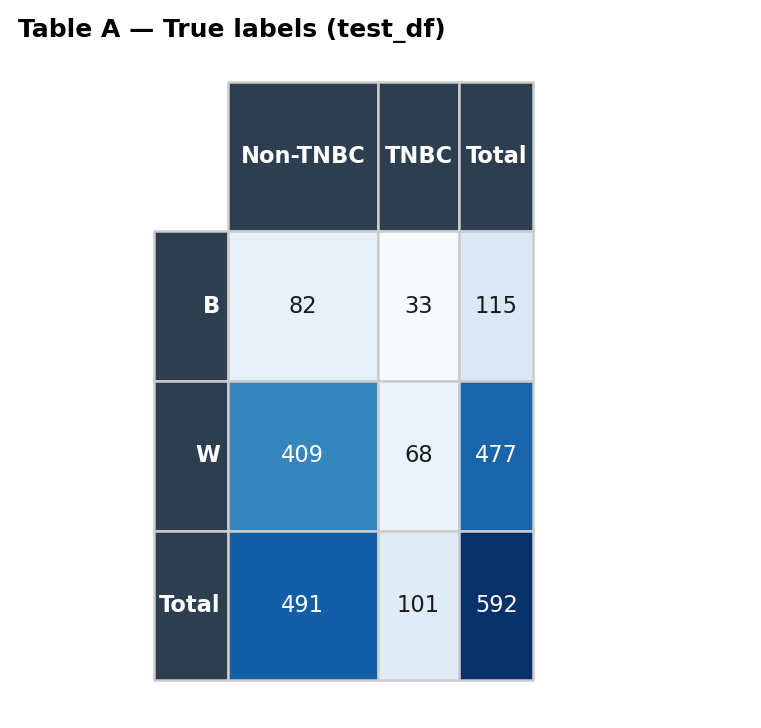
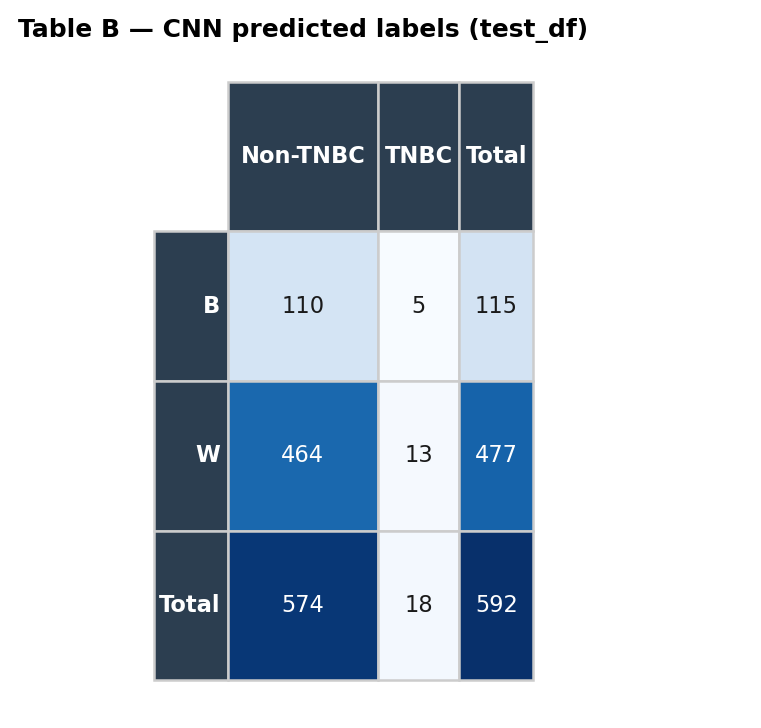
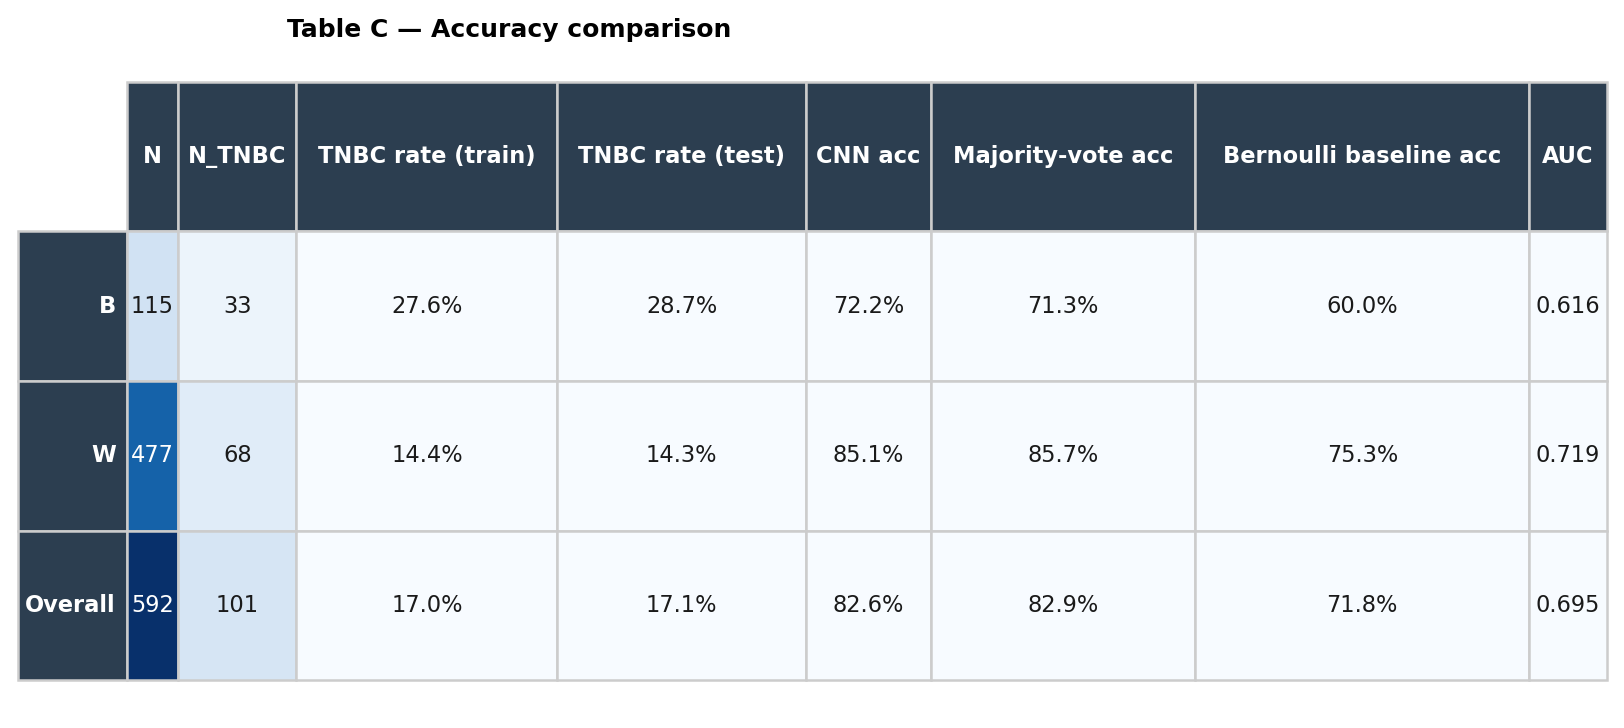
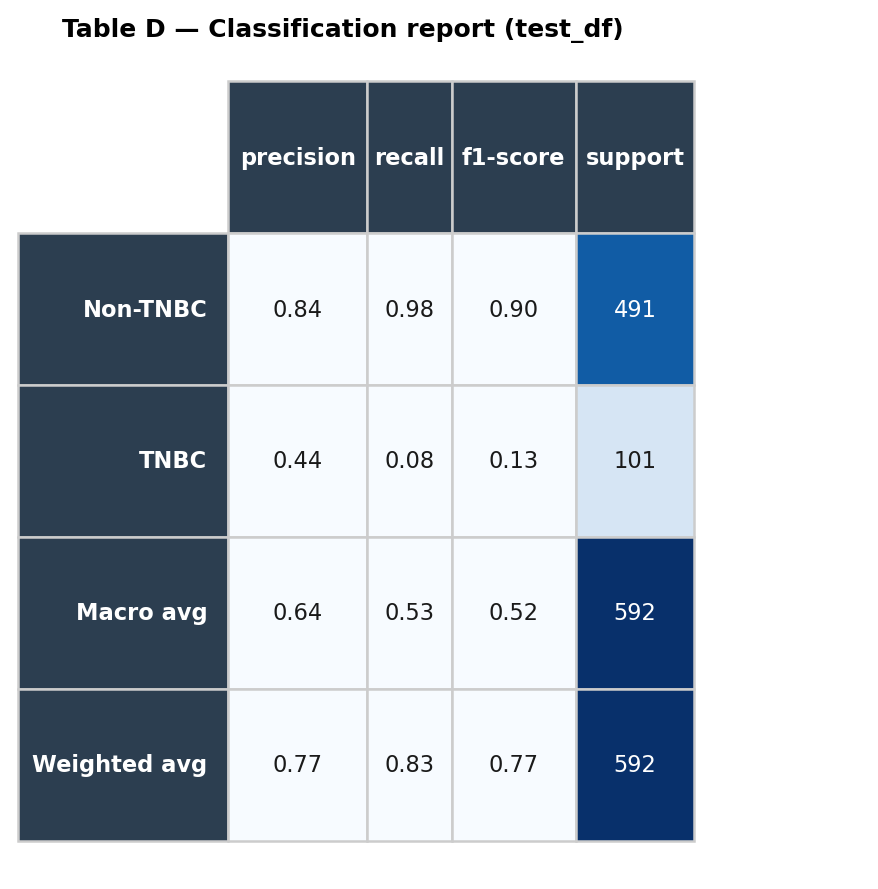
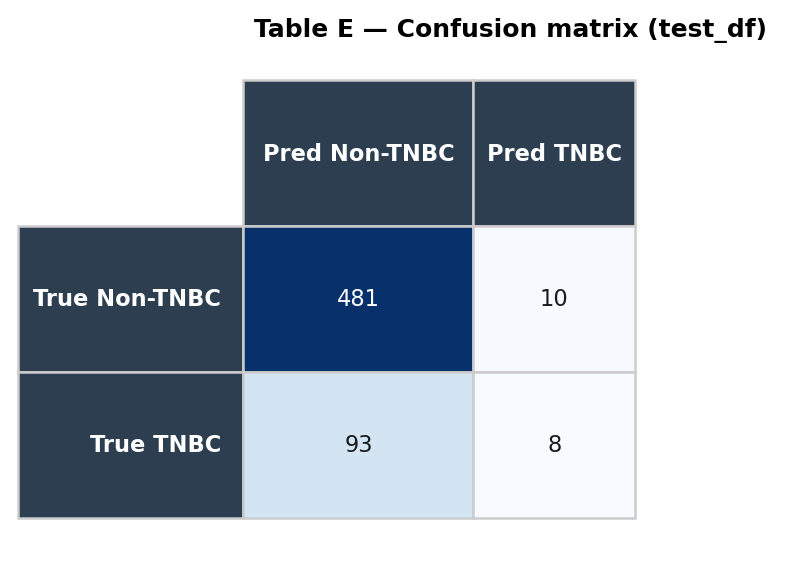

Files also saved to: /Users/ginniema/Desktop/Research/Active Inference (Candes)/Key examples/BRCA/table_exports/


In [13]:

# ── Export tables as CSV + PNG for presentations ──────────────────────────────
import base64, io, os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, HTML

EXPORT_DIR = "table_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── helper: render a DataFrame as a square-cell PNG with Blues heatmap ────────
def df_to_png(df, path, title="", col_fmt=None):
    """Save df as a PNG table with square cells and Blues heatmap on numeric data."""
    import matplotlib.colors as mcolors

    # apply formatting to get display strings
    disp = df.copy().astype(object)
    if col_fmt:
        for col, fmt in col_fmt.items():
            if col in disp.columns:
                disp[col] = disp[col].apply(lambda x: fmt.format(x))

    # extract raw numeric values for coloring (before formatting)
    num_df = df.copy()
    for col in num_df.columns:
        num_df[col] = pd.to_numeric(num_df[col], errors='coerce')

    n_rows, n_cols = disp.shape
    cell_size = 0.9                         # inches — square cells
    fig_w = cell_size * (n_cols + 1.6)
    fig_h = cell_size * (n_rows + 1.4)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10, fontweight='bold', pad=6, loc='left')

    tbl = ax.table(
        cellText  = disp.values,
        rowLabels = disp.index.tolist(),
        colLabels = disp.columns.tolist(),
        cellLoc   = 'center',
        rowLoc    = 'right',
        loc       = 'center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)

    # make cells square: set each cell's height = width
    tbl.auto_set_column_width(list(range(n_cols)))
    for (r, c), cell in tbl.get_celld().items():
        cell.set_height(cell_size / fig_h)
        cell.set_edgecolor('#cccccc')

    # Blues colormap for numeric data cells (normalise across whole table)
    cmap = plt.cm.Blues
    valid_vals = num_df.values[~np.isnan(num_df.values.astype(float))]
    vmin = float(np.nanmin(valid_vals)) if len(valid_vals) else 0
    vmax = float(np.nanmax(valid_vals)) if len(valid_vals) else 1
    if vmax == vmin:
        vmax = vmin + 1

    DARK, WHITE = '#2c3e50', '#ffffff'
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:                          # column header
            cell.set_facecolor(DARK)
            cell.get_text().set_color(WHITE)
            cell.get_text().set_fontweight('bold')
        elif c == -1:                       # row label
            cell.set_facecolor(DARK)
            cell.get_text().set_color(WHITE)
            cell.get_text().set_fontweight('bold')
        else:                               # data cell — Blues heatmap
            raw = num_df.iloc[r - 1, c] if (r - 1) < n_rows and c < n_cols else np.nan
            if pd.notna(raw):
                norm = (float(raw) - vmin) / (vmax - vmin)
                rgba = cmap(norm)
                cell.set_facecolor(mcolors.to_hex(rgba))
                cell.get_text().set_color(WHITE if norm > 0.55 else '#1a1a1a')
            else:
                cell.set_facecolor('#f9f9f9')

    plt.tight_layout(pad=0.4)
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# ── helper: create a clickable download link ──────────────────────────────────
def download_link(path, label):
    with open(path, 'rb') as f:
        data = base64.b64encode(f.read()).decode()
    ext  = os.path.splitext(path)[1].lstrip('.')
    mime = {'png': 'image/png', 'csv': 'text/csv'}.get(ext, 'application/octet-stream')
    fname = os.path.basename(path)
    return f'<a href="data:{mime};base64,{data}" download="{fname}">{label}</a>'

# ── format dicts ──────────────────────────────────────────────────────────────
acc_fmt = {c: "{:.1%}" for c in ["TNBC rate (train)", "TNBC rate (test)",
                                  "CNN acc", "Majority-vote acc",
                                  "Bernoulli baseline acc"]}
acc_fmt.update({"N": "{:.0f}", "N_TNBC": "{:.0f}", "AUC": "{:.3f}"})

cr_fmt  = {"precision": "{:.2f}", "recall": "{:.2f}",
           "f1-score": "{:.2f}", "support": "{:.0f}"}

# ── export each table ─────────────────────────────────────────────────────────
tables = [
    ("A_true_labels",       ct_true,  "Table A — True labels (test_df)",            None),
    ("B_predicted_labels",  ct_pred,  "Table B — CNN predicted labels (test_df)",   None),
    ("C_accuracy",          summary[["N","N_TNBC","TNBC rate (train)","TNBC rate (test)",
                                     "CNN acc","Majority-vote acc",
                                     "Bernoulli baseline acc","AUC"]],
                            "Table C — Accuracy comparison", acc_fmt),
    ("D_classification",    cr_df,    "Table D — Classification report (test_df)",  cr_fmt),
    ("E_confusion_matrix",  cm_df,    "Table E — Confusion matrix (test_df)",        None),
]

links_html = "<b>Download tables</b><br><table style='font-size:13px;border-collapse:collapse'>"
links_html += "<tr><th style='text-align:left;padding:4px 12px'>Table</th>"
links_html += "<th style='padding:4px 12px'>PNG</th><th style='padding:4px 12px'>CSV</th></tr>"

for slug, df, title, fmt in tables:
    png_path = f"{EXPORT_DIR}/{slug}.png"
    csv_path = f"{EXPORT_DIR}/{slug}.csv"
    df_to_png(df, png_path, title=title, col_fmt=fmt)
    df.to_csv(csv_path)
    links_html += (f"<tr><td style='padding:4px 12px'>{title}</td>"
                   f"<td style='text-align:center;padding:4px 12px'>{download_link(png_path, '⬇ PNG')}</td>"
                   f"<td style='text-align:center;padding:4px 12px'>{download_link(csv_path, '⬇ CSV')}</td></tr>")

links_html += "</table>"
display(HTML(links_html))
print(f"Files also saved to: {os.path.abspath(EXPORT_DIR)}/")


In [4]:
master_df = pd.read_csv('master_df_withpred.csv')

In [29]:
train_df.shape

(147, 14)

In [30]:
master_df.shape

(739, 14)

In [31]:
test_df.shape

(592, 14)

In [5]:
Yhat = np.array(master_df['predicted_probability'])
Y = np.array(master_df['is_tnbc']) * 1
white = np.array(master_df['race'] == "W")
Yhat1, Yhat0 = Yhat[white], Yhat[~white]
Y1, Y0 = Y[white], Y[~white]
n0, n1 = len(Y0), len(Y1)
n = n0 + n1

In [6]:
p0 = n0/(n0+n1)
p1 = n1/(n0+n1)

In [7]:
mu0, mu1 = Y0.mean(), Y1.mean()
true_odds_ratio = (mu1/(1 - mu1)) / (mu0/(1 - mu0))
true_var = (1/np.sum(Y0 == 0) + 1/np.sum(Y0==1) + 1/np.sum(Y1==0) + 1/np.sum(Y1==1)) * n

In [8]:
true_odds_ratio

0.4186991869918699

## Optimization code

In [14]:
# setup_spline_basis
def setup_spline_basis(uncertainties, num_knots=5, degree=3, name='u'):
    """
    Sets up B-spline basis functions for given uncertainties. 
    """
    if len(uncertainties) == 0:
        return np.zeros((0, 0)), None # Handle empty input
        
    # Ensure enough unique points relative to knots/degree
    unique_uncertainties = np.unique(uncertainties)
    required_unique = degree + 1 
    if len(unique_uncertainties) < required_unique:
         print(f"Warning: Need at least {required_unique} unique uncertainty points for degree {degree} spline, "
               f"found {len(unique_uncertainties)}. Reducing degree or complexity might be needed.")

    if len(unique_uncertainties) < num_knots + 1:
        num_knots = max(0, len(unique_uncertainties) - degree - 1) # Try to leave enough points between knots


    # Define knot locations (e.g., quantiles)
    knot_quantiles = np.linspace(0, 1, num_knots + 2)[1:-1] 
    
    # Handle case where all uncertainties are the same
    if len(unique_uncertainties) == 1:
         knots = np.array([]) # No internal knots
         num_knots = 0 # Force num_knots to 0
         # Use df instead of knots for constant case
         formula = f"bs({name}, df={degree+1}, degree={degree}, include_intercept=True) - 1"
         data = {name: uncertainties}
         try:
              basis_matrix = dmatrix(formula, data, return_type='dataframe')
              return basis_matrix.values, None
         except Exception as e:
             print(f"Patsy error even with df for constant uncertainty: {e}. Returning basic constant basis.")
             # Fallback to a truly constant basis (vector of ones)
             return np.ones((len(uncertainties), 1)), None


    # Proceed with knot calculation for non-constant cases
    if num_knots > 0:
         knots = np.quantile(uncertainties, knot_quantiles)
         knots = np.unique(knots) # Ensure knots are unique
         # Check if knots collapsed or are too close to boundaries
         min_u, max_u = np.min(uncertainties), np.max(uncertainties)
         # Remove knots too close to the boundary? Sometimes helps patsy.
         # knots = knots[(knots > min_u) & (knots < max_u)] 
         if len(knots) < num_knots:
              # print(f"Warning: Number of unique knots reduced to {len(knots)}.")
              pass # Let patsy handle fewer knots
         if len(knots) == 0 and num_knots > 0:
              print("Warning: All internal knots collapsed. Proceeding without internal knots.")
              num_knots = 0 # Update num_knots if they vanished

    else: # num_knots is 0
         knots = np.array([])

    # Create the design matrix using patsy
    # Use bs() for B-splines
    if num_knots > 0:
        formula = f"bs({name}, knots=knots, degree=degree, include_intercept=True) - 1"
    else: # No internal knots, use df
         df = degree + 1 # Number of basis functions for degree d, no internal knots
         formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True) - 1"

    data = {name: uncertainties}
    
    try:
        basis_matrix = dmatrix(formula, data, return_type='dataframe')
    except Exception as e:
         print(f"Patsy error: {e}. Trying simpler df if knots were used.")
         try:
             # Fallback if specific knot creation failed
             df = num_knots + degree + 1 # Total degrees of freedom expected
             formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True) - 1"
             basis_matrix = dmatrix(formula, data, return_type='dataframe')
             knots = None # Knots aren't explicitly defined in this case
         except Exception as e2:
             print(f"Patsy fallback failed: {e2}. Returning basic constant basis.")
             return np.ones((len(uncertainties), 1)), None


    # Check if basis matrix has expected shape
    expected_cols = num_knots + degree + 1 # Intercept is included in the count here
    if basis_matrix.shape[1] == 0 and expected_cols > 0 :
         print(f"Warning: Patsy generated an empty basis matrix ({basis_matrix.shape}). Check inputs/parameters. Returning constant basis.")
         return np.ones((len(uncertainties), 1)), None
         
    return basis_matrix.values, knots # Return as numpy array



In [17]:
def sampling_probs_spline_inv(u1_all, u0_all, b1, b0, mu1, mu0, n_budget, num_knots=5, degree=3, verbose_solver=False):
    """
    Compute optimal sampling probabilities parametrized by splines on INVERSE probabilities.
    MODIFIED TO PRIORITIZE MOSEK SOLVER.

    Models log(1/p_i) = B(u_i) @ theta, such that 1/p_i >= 1.

    Args:
        u1_all (np.ndarray): Individual uncertainty scores for group 1 points.
        u0_all (np.ndarray): Individual uncertainty scores for group 0 points.
        b1 (np.ndarray): individual scores (potentially diff from uncertainty scores) for constructing spline basis for group 1 points.
        b0 (np.ndarray): individual scores ("") for constructing spline basis for group 0 points.
        mu1 (float): Estimated mean for group 1 (used for scaling objective).
        mu0 (float): Estimated mean for group 0 (used for scaling objective).
        n_budget (float): Total expected sample budget.
        num_knots (int): Number of internal knots for the splines.
        degree (int): Degree of the spline polynomials.
        verbose_solver (bool): If True, show detailed solver output.

    Returns:
        tuple: (probs1, probs0, spline_params1, spline_params0)
               probs1 (np.ndarray): Sampling probabilities for group 1 points.
               probs0 (np.ndarray): Sampling probabilities for group 0 points.
               spline_params1 (dict): Info about group 1 spline (coeffs, knots, degree).
               spline_params0 (dict): Info about group 0 spline (coeffs, knots, degree).
        Returns (None, None, None, None) if optimization fails.
    """
    overall_start_time = time.perf_counter()
    n1 = len(u1_all)
    n0 = len(u0_all)

    if n1 == 0 and n0 == 0:
        print("Warning: Both groups are empty.")
        return np.array([]), np.array([]), None, None
    if n_budget <= 0:
         print("Warning: Budget is non-positive. Returning zero probabilities.")
         return np.zeros(n1), np.zeros(n0), None, None

    # --- Setup Spline Basis (Same as before) ---
    B1, knots1 = np.zeros((n1, 0)), None
    B0, knots0 = np.zeros((n0, 0)), None
    n_basis1 = 0
    n_basis0 = 0

    if n1 > 0:
        try:
             #B1, knots1 = setup_spline_basis(u1_all, num_knots, degree, name='u1')
             B1, knots1 = setup_spline_basis(b1, num_knots, degree, name = 'u1')
             n_basis1 = B1.shape[1]
             if n_basis1 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
            print(f"Could not create spline basis for group 1: {e}. Check uncertainty values.")
            n_basis1 = 0 # Ensure it's zero
    if n0 > 0:
        try:
            B0, knots0 = setup_spline_basis(b0, num_knots, degree, name = 'u0')
            #B0, knots0 = setup_spline_basis(u0_all, num_knots, degree, name='u0')
            n_basis0 = B0.shape[1]
            if n_basis0 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
             print(f"Could not create spline basis for group 0: {e}. Check uncertainty values.")
             n_basis0 = 0 # Ensure it's zero

    if n_basis1 == 0 and n_basis0 == 0 and (n1 > 0 or n0 > 0):
         print("Error: Could not create spline basis for either group. Cannot optimize.")
         return None, None, None, None

    # --- CVXPY Optimization
    theta1 = cp.Variable(n_basis1, name="theta1") if n_basis1 > 0 else None
    theta0 = cp.Variable(n_basis0, name="theta0") if n_basis0 > 0 else None

    log_x1, log_x0 = None, None
    x1, x0 = None, None
    p1, p0 = None, None

    constraints = []
    objective_terms = []
    budget_terms = []

    # Group 1 calculations
    if n1 > 0 and n_basis1 > 0 and theta1 is not None and mu1 > 0 and mu1 < 1:
        w1 = u1_all / (n1**2 * (mu1**2) * (1 - mu1)**2)
        log_x1 = B1 @ theta1
        x1 = cp.exp(log_x1)
        p1 = cp.exp(-log_x1)
        objective_terms.append(cp.sum(cp.multiply(w1, x1)))
        budget_terms.append(cp.sum(p1))
        #budget_terms.append(-log_x1)
        constraints.append(log_x1 >= 0)
    elif n1 > 0:
         print(f"Warning: Skipping group 1 contributions (n1={n1}, n_basis1={n_basis1}, mu1={mu1})")

    # Group 0 calculations
    if n0 > 0 and n_basis0 > 0 and theta0 is not None and mu0 > 0 and mu0 < 1:
        w0 = u0_all / (n0**2 * (mu0**2) * (1 - mu0)**2)
        log_x0 = B0 @ theta0
        x0 = cp.exp(log_x0)
        p0 = cp.exp(-log_x0)
        objective_terms.append(cp.sum(cp.multiply(w0, x0)))
        budget_terms.append(cp.sum(p0))
        #budget_terms.append(-log_x0)
        constraints.append(log_x0 >= 0)
    elif n0 > 0:
        print(f"Warning: Skipping group 0 contributions (n0={n0}, n_basis0={n_basis0}, mu0={mu0})")

    if not objective_terms:
         print("Error: No valid objective terms could be constructed.")
         return None, None, None, None

    # Objective function: Minimize sum of weighted inverse probabilities (w_i * x_i)
    objective = cp.Minimize(cp.sum(objective_terms))

    # Budget Constraint: sum(p_i) <= n_budget
    if budget_terms: # Only add budget constraint if there are probabilities to sum
        constraints.append(cp.sum(budget_terms) <= n_budget)
        #log_xs = cp.multiply(np.ones(len(budget_terms), budget_terms))
        #constraints.append(cp.log_sum_exp(-cp.hstack(budget_terms)) <= cp.log(n_budget))
    else:
         print("Warning: No variables to constrain budget.")

    problem = cp.Problem(objective, constraints)

    # --- Solve the problem with MOSEK, falling back to ECOS, then SCS ---
    # Define solver priority list
    solver_list = [cp.MOSEK, cp.ECOS, cp.SCS]
    solved = False

    for solver_name in solver_list: # solver_name is 'MOSEK', 'ECOS', or 'SCS'

        #print(f"Attempting to solve with {solver_name}...")
        try:
            # --- Solver Specific Arguments & Options ---
            # Start with common arguments
            solver_kwargs = {
                'verbose': verbose_solver,
                # General tolerance arguments might be added here,
                # but specific ones are often better handled below.
            }

            # --- Configure solver-specific arguments ---

            if solver_name == cp.ECOS: # Or just 'ECOS'
                 # ECOS takes arguments directly
                 solver_kwargs['max_iters'] = 200
                 solver_kwargs['abstol'] = 1e-8 # Example specific tolerances
                 solver_kwargs['reltol'] = 1e-7

            elif solver_name == cp.SCS: # Or just 'SCS'
                 # SCS takes arguments directly
                 solver_kwargs['eps'] = 1e-5 # Example specific tolerance

            # --- Solve ---
            # Unpack the prepared kwargs dictionary. If solver is MOSEK,
            # this will now directly pass MSK_DPAR... arguments.
            #print(f"Passing kwargs to {solver_name}: {solver_kwargs}") # Debug print
            problem.solve(solver=solver_name, **solver_kwargs)
            final_status = problem.status

            # --- Check Status ---
            # If solved optimally or inaccurately, stop trying other solvers
            if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                #print(f"{solver_name} finished with status: {problem.status}")
                solved = True
                break # Exit the loop
            else:
                print(f"{solver_name} failed with status: {problem.status}")
                # Continue to the next solver in the list

        except (cp.SolverError, ValueError, ImportError) as e:
             # ImportError can happen if solver seems installed but has runtime issues (e.g., MOSEK license)
            print(f"{solver_name} solver encountered an error: {e}")
            # Continue to the next solver in the list

    if not solved:
        print("All attempted solvers failed to find an optimal or inaccurate solution.")
        # Ensure problem status reflects the failure if loop finishes without success
        if problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
             problem.status = "solver_error"


    # --- Check for solution (rest of the code is the same) ---
    overall_end_time = time.perf_counter()
    if problem.status in ["optimal", "optimal_inaccurate"]:
        #print(f"Optimization successful (Final Status: {problem.status}). Objective value: {problem.value}")
        #print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds") # Added total time

        final_probs1 = np.zeros(n1)
        final_probs0 = np.zeros(n0)
        final_theta1 = None
        final_theta0 = None

        # Retrieve results safely (check if variables and .value exist)
        if p1 is not None and theta1 is not None and hasattr(theta1, 'value') and theta1.value is not None:
            final_theta1 = theta1.value
            try:
                 log_x1_opt = B1 @ final_theta1
                 final_probs1 = np.exp(-log_x1_opt)
                 final_probs1 = np.clip(final_probs1, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 1: {calc_e}")
                 final_probs1 = np.zeros(n1) # Fallback
                 final_theta1 = None # Invalidate theta if calc failed

        if p0 is not None and theta0 is not None and hasattr(theta0, 'value') and theta0.value is not None:
            final_theta0 = theta0.value
            try:
                log_x0_opt = B0 @ final_theta0
                final_probs0 = np.exp(-log_x0_opt)
                final_probs0 = np.clip(final_probs0, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 0: {calc_e}")
                 final_probs0 = np.zeros(n0) # Fallback
                 final_theta0 = None # Invalidate theta if calc failed

        # Store spline parameters
        spline_params1 = {'coeffs': final_theta1, 'knots': knots1, 'degree': degree, 'n_basis': n_basis1} if n_basis1 > 0 and final_theta1 is not None else None
        spline_params0 = {'coeffs': final_theta0, 'knots': knots0, 'degree': degree, 'n_basis': n_basis0} if n_basis0 > 0 and final_theta0 is not None else None

        # Sanity check budget constraint
        actual_expected_samples = np.sum(final_probs1) + np.sum(final_probs0)
        # Use a slightly larger tolerance for feasibility checks after solve
        # Check against 1% deviation or a small absolute value
        upper_bound = max(n_budget * 1.01, n_budget + 1e-4)
        lower_bound = min(n_budget * 0.99, n_budget - 1e-4)

        if actual_expected_samples > upper_bound:
             print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"significantly exceed budget ({n_budget:.4f}). Status: {problem.status}")
        # Check for underutilization only if budget likely should have been tight (objective > 0)
        elif actual_expected_samples < lower_bound and abs(problem.value) > 1e-6:
              print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"is significantly under budget ({n_budget:.4f}). Solution might be suboptimal if budget wasn't tight.")


        return final_probs1, final_probs0, spline_params1, spline_params0

    else:
        print(f"Problem not solved optimally. Final Status: {problem.status}")
        print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds")
        return None, None, None, None

In [16]:
# with even split for the two groups
def sampling_probs_spline_inv(u1_all, u0_all, b1, b0, mu1, mu0, n_budget, num_knots=5, degree=3, verbose_solver=False):
    """
    Compute optimal sampling probabilities parametrized by splines on INVERSE probabilities.
    MODIFIED TO PRIORITIZE MOSEK SOLVER.

    Models log(1/p_i) = B(u_i) @ theta, such that 1/p_i >= 1.

    Args:
        u1_all (np.ndarray): Individual uncertainty scores for group 1 points.
        u0_all (np.ndarray): Individual uncertainty scores for group 0 points.
        b1 (np.ndarray): individual scores (potentially diff from uncertainty scores) for constructing spline basis for group 1 points.
        b0 (np.ndarray): individual scores ("") for constructing spline basis for group 0 points.
        mu1 (float): Estimated mean for group 1 (used for scaling objective).
        mu0 (float): Estimated mean for group 0 (used for scaling objective).
        n_budget (float): Total expected sample budget.
        num_knots (int): Number of internal knots for the splines.
        degree (int): Degree of the spline polynomials.
        verbose_solver (bool): If True, show detailed solver output.

    Returns:
        tuple: (probs1, probs0, spline_params1, spline_params0)
               probs1 (np.ndarray): Sampling probabilities for group 1 points.
               probs0 (np.ndarray): Sampling probabilities for group 0 points.
               spline_params1 (dict): Info about group 1 spline (coeffs, knots, degree).
               spline_params0 (dict): Info about group 0 spline (coeffs, knots, degree).
        Returns (None, None, None, None) if optimization fails.
    """
    overall_start_time = time.perf_counter()
    n1 = len(u1_all)
    n0 = len(u0_all)

    if n1 == 0 and n0 == 0:
        print("Warning: Both groups are empty.")
        return np.array([]), np.array([]), None, None
    if n_budget <= 0:
         print("Warning: Budget is non-positive. Returning zero probabilities.")
         return np.zeros(n1), np.zeros(n0), None, None

    # --- Setup Spline Basis (Same as before) ---
    B1, knots1 = np.zeros((n1, 0)), None
    B0, knots0 = np.zeros((n0, 0)), None
    n_basis1 = 0
    n_basis0 = 0

    if n1 > 0:
        try:
             #B1, knots1 = setup_spline_basis(u1_all, num_knots, degree, name='u1')
             B1, knots1 = setup_spline_basis(b1, num_knots, degree, name = 'u1')
             n_basis1 = B1.shape[1]
             if n_basis1 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
            print(f"Could not create spline basis for group 1: {e}. Check uncertainty values.")
            n_basis1 = 0 # Ensure it's zero
    if n0 > 0:
        try:
            B0, knots0 = setup_spline_basis(b0, num_knots, degree, name = 'u0')
            #B0, knots0 = setup_spline_basis(u0_all, num_knots, degree, name='u0')
            n_basis0 = B0.shape[1]
            if n_basis0 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
             print(f"Could not create spline basis for group 0: {e}. Check uncertainty values.")
             n_basis0 = 0 # Ensure it's zero

    if n_basis1 == 0 and n_basis0 == 0 and (n1 > 0 or n0 > 0):
         print("Error: Could not create spline basis for either group. Cannot optimize.")
         return None, None, None, None

    # --- CVXPY Optimization
    theta1 = cp.Variable(n_basis1, name="theta1") if n_basis1 > 0 else None
    theta0 = cp.Variable(n_basis0, name="theta0") if n_basis0 > 0 else None

    log_x1, log_x0 = None, None
    x1, x0 = None, None
    p1, p0 = None, None

    constraints = []
    objective_terms = []
    budget_terms1, budget_terms0 = [], []

    # Group 1 calculations
    if n1 > 0 and n_basis1 > 0 and theta1 is not None and mu1 > 0 and mu1 < 1:
        w1 = u1_all / (n1**2 * (mu1**2) * (1 - mu1)**2)
        log_x1 = B1 @ theta1
        x1 = cp.exp(log_x1)
        p1 = cp.exp(-log_x1)
        objective_terms.append(cp.sum(cp.multiply(w1, x1)))
        budget_terms1.append(cp.sum(p1))
        #budget_terms.append(-log_x1)
        constraints.append(log_x1 >= 0)
    elif n1 > 0:
         print(f"Warning: Skipping group 1 contributions (n1={n1}, n_basis1={n_basis1}, mu1={mu1})")

    # Group 0 calculations
    if n0 > 0 and n_basis0 > 0 and theta0 is not None and mu0 > 0 and mu0 < 1:
        w0 = u0_all / (n0**2 * (mu0**2) * (1 - mu0)**2)
        log_x0 = B0 @ theta0
        x0 = cp.exp(log_x0)
        p0 = cp.exp(-log_x0)
        objective_terms.append(cp.sum(cp.multiply(w0, x0)))
        budget_terms0.append(cp.sum(p0))
        #budget_terms.append(-log_x0)
        constraints.append(log_x0 >= 0)
    elif n0 > 0:
        print(f"Warning: Skipping group 0 contributions (n0={n0}, n_basis0={n_basis0}, mu0={mu0})")

    if not objective_terms:
         print("Error: No valid objective terms could be constructed.")
         return None, None, None, None

    # Objective function: Minimize sum of weighted inverse probabilities (w_i * x_i)
    objective = cp.Minimize(cp.sum(objective_terms))

    # Budget Constraint: sum(p_i) <= n_budget
    if budget_terms1 or budget_terms0: # Only add budget constraint if there are probabilities to sum
        constraints.append(cp.sum(budget_terms1) <= n_budget / 2)
        constraints.append(cp.sum(budget_terms0) <= n_budget / 2)
        #log_xs = cp.multiply(np.ones(len(budget_terms), budget_terms))
        #constraints.append(cp.log_sum_exp(-cp.hstack(budget_terms)) <= cp.log(n_budget))
    else:
         print("Warning: No variables to constrain budget.")

    problem = cp.Problem(objective, constraints)

    # --- Solve the problem with MOSEK, falling back to ECOS, then SCS ---
    # Define solver priority list
    solver_list = [cp.MOSEK, cp.ECOS, cp.SCS]
    solved = False

    for solver_name in solver_list: # solver_name is 'MOSEK', 'ECOS', or 'SCS'

        #print(f"Attempting to solve with {solver_name}...")
        try:
            # --- Solver Specific Arguments & Options ---
            # Start with common arguments
            solver_kwargs = {
                'verbose': verbose_solver,
                # General tolerance arguments might be added here,
                # but specific ones are often better handled below.
            }

            # --- Configure solver-specific arguments ---

            if solver_name == cp.ECOS: # Or just 'ECOS'
                 # ECOS takes arguments directly
                 solver_kwargs['max_iters'] = 200
                 solver_kwargs['abstol'] = 1e-8 # Example specific tolerances
                 solver_kwargs['reltol'] = 1e-7

            elif solver_name == cp.SCS: # Or just 'SCS'
                 # SCS takes arguments directly
                 solver_kwargs['eps'] = 1e-5 # Example specific tolerance

            # --- Solve ---
            # Unpack the prepared kwargs dictionary. If solver is MOSEK,
            # this will now directly pass MSK_DPAR... arguments.
            #print(f"Passing kwargs to {solver_name}: {solver_kwargs}") # Debug print
            problem.solve(solver=solver_name, **solver_kwargs)
            final_status = problem.status

            # --- Check Status ---
            # If solved optimally or inaccurately, stop trying other solvers
            if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                #print(f"{solver_name} finished with status: {problem.status}")
                solved = True
                break # Exit the loop
            else:
                print(f"{solver_name} failed with status: {problem.status}")
                # Continue to the next solver in the list

        except (cp.SolverError, ValueError, ImportError) as e:
             # ImportError can happen if solver seems installed but has runtime issues (e.g., MOSEK license)
            print(f"{solver_name} solver encountered an error: {e}")
            # Continue to the next solver in the list

    if not solved:
        print("All attempted solvers failed to find an optimal or inaccurate solution.")
        # Ensure problem status reflects the failure if loop finishes without success
        if problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
             problem.status = "solver_error"


    # --- Check for solution (rest of the code is the same) ---
    overall_end_time = time.perf_counter()
    if problem.status in ["optimal", "optimal_inaccurate"]:
        #print(f"Optimization successful (Final Status: {problem.status}). Objective value: {problem.value}")
        #print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds") # Added total time

        final_probs1 = np.zeros(n1)
        final_probs0 = np.zeros(n0)
        final_theta1 = None
        final_theta0 = None

        # Retrieve results safely (check if variables and .value exist)
        if p1 is not None and theta1 is not None and hasattr(theta1, 'value') and theta1.value is not None:
            final_theta1 = theta1.value
            try:
                 log_x1_opt = B1 @ final_theta1
                 final_probs1 = np.exp(-log_x1_opt)
                 final_probs1 = np.clip(final_probs1, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 1: {calc_e}")
                 final_probs1 = np.zeros(n1) # Fallback
                 final_theta1 = None # Invalidate theta if calc failed

        if p0 is not None and theta0 is not None and hasattr(theta0, 'value') and theta0.value is not None:
            final_theta0 = theta0.value
            try:
                log_x0_opt = B0 @ final_theta0
                final_probs0 = np.exp(-log_x0_opt)
                final_probs0 = np.clip(final_probs0, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 0: {calc_e}")
                 final_probs0 = np.zeros(n0) # Fallback
                 final_theta0 = None # Invalidate theta if calc failed

        # Store spline parameters
        spline_params1 = {'coeffs': final_theta1, 'knots': knots1, 'degree': degree, 'n_basis': n_basis1} if n_basis1 > 0 and final_theta1 is not None else None
        spline_params0 = {'coeffs': final_theta0, 'knots': knots0, 'degree': degree, 'n_basis': n_basis0} if n_basis0 > 0 and final_theta0 is not None else None

        # Sanity check budget constraint
        actual_expected_samples = np.sum(final_probs1) + np.sum(final_probs0)
        # Use a slightly larger tolerance for feasibility checks after solve
        # Check against 1% deviation or a small absolute value
        upper_bound = max(n_budget * 1.01, n_budget + 1e-4)
        lower_bound = min(n_budget * 0.99, n_budget - 1e-4)

        if actual_expected_samples > upper_bound:
             print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"significantly exceed budget ({n_budget:.4f}). Status: {problem.status}")
        # Check for underutilization only if budget likely should have been tight (objective > 0)
        elif actual_expected_samples < lower_bound and abs(problem.value) > 1e-6:
              print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"is significantly under budget ({n_budget:.4f}). Solution might be suboptimal if budget wasn't tight.")


        return final_probs1, final_probs0, spline_params1, spline_params0

    else:
        print(f"Problem not solved optimally. Final Status: {problem.status}")
        print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds")
        return None, None, None, None

## Helper functions

In [ ]:
def opt_mean_tuning(Y, Yhat, weights, sampling_ratio): #lambda star is sum of Y * f where f is Yhat * weights * sampling ratio
    return np.clip(np.mean(Y*Yhat*weights*sampling_ratio)/np.mean(Yhat**2*sampling_ratio), 0, 1)

def odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights0, weights1, pi0, pi1, alpha, lhat0=None, lhat1=None):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    mu0_hat = np.mean(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*weights0)
    mu1_hat = np.mean(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*weights1)
    pointest_log = np.log(mu1_hat/(1-mu1_hat)) - np.log(mu0_hat/(1-mu0_hat))
    var_mu0_hat = 
    #var_mu0_hat = np.var(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*weights0)
    #var_mu1_hat = np.var(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*weights1)
    var0 = var_mu0_hat/((mu0_hat*(1-mu0_hat))**2)
    var1 = var_mu1_hat/((mu1_hat*(1-mu1_hat))**2)
    p0 = n0/(n0+n1)
    p1 = n1/(n0+n1)
    var = 1/p0*var0 + 1/p1*var1
    width_log = norm.ppf(1-alpha/2)*np.sqrt(var/(n0+n1))
    return np.exp(pointest_log - width_log), np.exp(pointest_log + width_log), var

In [12]:
frac_human = 0.2
uncertainty0 = np.minimum(Yhat0, 1-Yhat0)
uncertainty1 = np.minimum(Yhat1, 1-Yhat1)
eta0 = frac_human / np.mean(uncertainty0)
eta1 = frac_human / np.mean(uncertainty1)

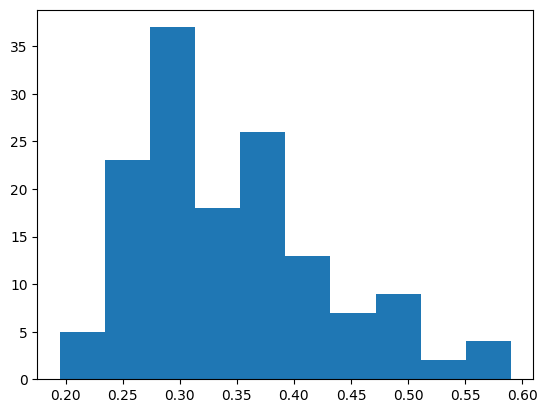

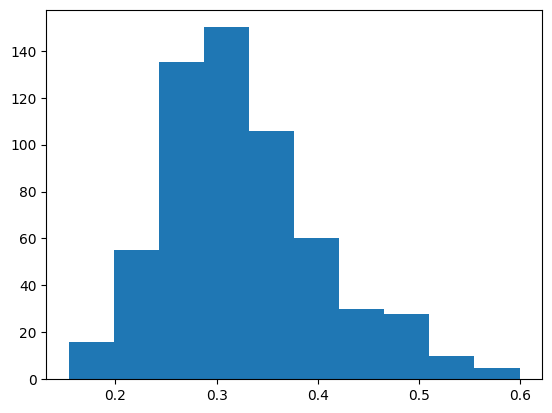

In [13]:
plt.hist(Yhat0) #african american
plt.show()
plt.hist(Yhat1) #white
plt.show()


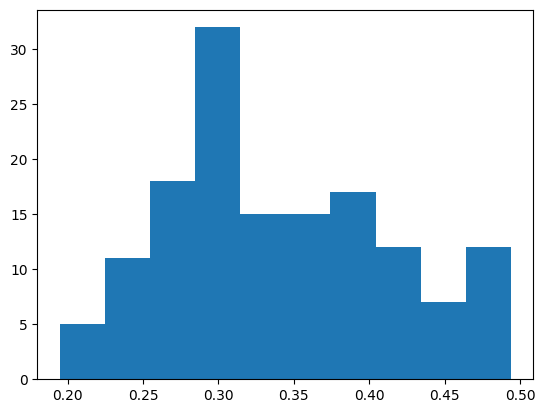

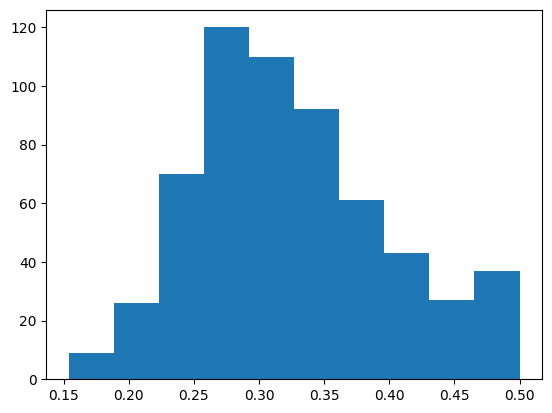

In [14]:
plt.hist(uncertainty0)
plt.show()
plt.hist(uncertainty1)
plt.show()
# uncertainty is like a confidence score, can we then train a gradient boosted tree using the uncertainties as confidence scores, as in the previous
# or confidence is np.maximum(Yhat, 1 - Yhat)...? maybe try this and see what happens

In [15]:
def sample_ci(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B, alpha, budget, tau, lhat0_A=None, lhat1_A=None, lhat0_B=None, lhat1_B=None):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    probs0_A = np.clip(tau*probs0_A + (1-tau)*budget, 0, 1)
    probs1_A = np.clip(tau*probs1_A + (1-tau)*budget, 0, 1)
    probs0_B = np.clip(tau*probs0_B + (1-tau)*budget, 0, 1)
    probs1_B = np.clip(tau*probs1_B + (1-tau)*budget, 0, 1)
    
    # draw uniforms for coupling
    U0, U1 = np.random.rand(n0), np.random.rand(n1)
    xi0_A, xi0_B = U0 <= probs0_A, U0 <= probs0_B
    xi1_A, xi1_B = U1 <= probs1_A, U1 <= probs1_B

    # compute estimates
    mu0_hatA = np.mean(lhat0_A*Yhat0 + (Y0 - lhat0_A*Yhat0)*xi0_A/probs0_A)
    mu1_hatA = np.mean(lhat1_A*Yhat1 + (Y1 - lhat1_A*Yhat1)*xi1_A/probs1_A)
    mu0_hatB = np.mean(lhat0_B*Yhat0 + (Y0 - lhat0_B*Yhat0)*xi0_B/probs0_B)
    mu1_hatB = np.mean(lhat1_B*Yhat1 + (Y1 - lhat1_B*Yhat1)*xi1_B/probs1_B)
    pointest_logA = np.log(mu1_hatA/(1-mu1_hatA)) - np.log(mu0_hatA/(1-mu0_hatA))
    pointest_logB = np.log(mu1_hatB/(1-mu1_hatB)) - np.log(mu0_hatB/(1-mu0_hatB))
    
    # compute variances
    var_mu0_hatA = np.var(lhat0_A*Yhat0 + (Y0 - lhat0_A*Yhat0)*xi0_A/probs0_A)
    var_mu1_hatA = np.var(lhat1_A*Yhat1 + (Y1 - lhat1_A*Yhat1)*xi1_A/probs1_A)
    var_mu0_hatB = np.var(lhat0_B*Yhat0 + (Y0 - lhat0_B*Yhat0)*xi0_B/probs0_B)
    var_mu1_hatB = np.var(lhat1_B*Yhat1 + (Y1 - lhat1_B*Yhat1)*xi1_B/probs1_B)
    var0_A = var_mu0_hatA/((mu0_hatA*(1-mu0_hatA))**2)
    var1_A = var_mu1_hatA/((mu1_hatA*(1-mu1_hatA))**2)
    var0_B = var_mu0_hatB/((mu0_hatB*(1-mu0_hatB))**2)
    var1_B = var_mu1_hatB/((mu1_hatB*(1-mu1_hatB))**2)
    p0 = n0/(n0+n1)
    p1 = n1/(n0+n1)
    var_A = 1/p0*var0_A + 1/p1*var1_A
    var_B = 1/p0*var0_B + 1/p1*var1_B
    width_logA = norm.ppf(1-alpha/2)*np.sqrt(var_A/(n0+n1))
    width_logB = norm.ppf(1-alpha/2)*np.sqrt(var_B/(n0+n1))
    l_A, u_A = np.exp(pointest_logA - width_logA), np.exp(pointest_logA + width_logA)
    l_B, u_B = np.exp(pointest_logB - width_logB), np.exp(pointest_logB + width_logB)
    return l_A, u_A, var_A, l_B, u_B, var_B
    #return l_A, u_A, var_A, probs0_A, probs1_A, np.where(xi0_A == 1), np.where(xi1_A == 1), l_B, u_B, var_B, probs0_B, probs1_B, np.where(xi0_B == 1), np.where(xi1_B == 1)

## Plotting code

In [16]:
def plot_eff_sample_size(df, plot_title):
    df = df[df.estimator != "LLM only"]
    ylab = "$n_{\mathrm{effective}}$"
    xlab = "$n_{\mathrm{human}}$"

    desired_order = ["active", "active + tuning", 
                     "spline", "spline + tuning", 
                     "uniform", "classical"]

    color_map = {"active": 'tab:orange', 
                 "active + tuning": 'tab:orange',
                 "spline": 'tab:green',
                 "spline + tuning": 'tab:green',
                 "uniform": 'tab:blue',
                 "classical": 'tab:purple'}
    
    linestyle_map = {
        "active": "-",
        "active + tuning": "--",   # dashed
        "spline": "-",
        "spline + tuning": "--",
        "uniform": "-",
        "classical": "-"
    }

    markers = ["o", "o", "s", "s", "D", "X"]  # Different marker shapes
    sns.set_theme(font_scale=2.2, style='white', rc={'lines.linewidth': 3})
    df_mean = df.groupby([xlab, 'estimator'])[ylab].mean().reset_index()
    df_lower = df.groupby([xlab, 'estimator'])[ylab].quantile(0.25).reset_index()
    df_upper = df.groupby([xlab, 'estimator'])[ylab].quantile(0.75).reset_index()
    fig, ax = plt.subplots(figsize=(7, 8))

    eff_frac = (df[xlab] / n) * 100

    for i, est in enumerate(desired_order):
        subset = df_mean[df_mean['estimator'] == est]
        subset_lower = df_lower[df_lower['estimator'] == est]
        subset_upper = df_upper[df_upper['estimator'] == est]
        ax.plot(subset[xlab], subset[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                #linestyle='-' if dashes_map[est] == "" else None,
                #dashes=None if dashes_map[est] == "" else dashes_map[est],
                marker=markers[i],
                markersize=10,
                linewidth=2)
        # ax.fill_between(subset[xlab], subset_lower[ylab], subset_upper[ylab],
        #                 color=color_map[est],
        #                 alpha=0.2)
    
    #n_vals = np.sort(df[xlab].unique())
    n_vals = np.linspace(0.2, 0.8, 7)
    tick_labels = []
    for i in n_vals:
       tick_labels.append(f"{i * n}\n({n_vals[i] * 100:.0%})")

    ax.set_xticks(n_vals)
    ax.set_xticklabels(tick_labels)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(top=True, right=True)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend().remove()

    #ax.set_yticks(np.arange(100, 500+1, 100))

    # making a fake legend
    
    
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()
    # sns.lineplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax,
    #              style='estimator', markers=markers, linewidth=2, alpha=0.7, legend=False)
    # sns.scatterplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax, s=70, alpha=0.7, edgecolor='black', style='estimator', markers=markers)
    # ax.legend().remove()
    # ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    # sns.despine(top=True, right=True)
    # plt.tight_layout()
    # plt.savefig(plot_title, bbox_inches='tight')
    # plt.show()

In [17]:
np.linspace(0.2, 0.8, 7)


array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

In [18]:
df = df[df.estimator != "LLM only"]
ylab = "$n_{\mathrm{effective}}$"
xlab = "$n_{\mathrm{human}}$"

desired_order = ["active", "active + tuning", 
                    "spline", "spline + tuning", 
                    "uniform", "classical"]

color_map = {"active": 'tab:orange', 
                "active + tuning": 'tab:orange',
                "spline": 'tab:green',
                "spline + tuning": 'tab:green',
                "uniform": 'tab:blue',
                "classical": 'tab:purple'}

linestyle_map = {
    "active": "-",
    "active + tuning": "--",   # dashed
    "spline": "-",
    "spline + tuning": "--",
    "uniform": "-",
    "classical": "-"
}

markers = ["o", "o", "s", "s", "D", "X"]  # Different marker shapes
sns.set_theme(font_scale=2.2, style='white', rc={'lines.linewidth': 3})
df_mean = df.groupby([xlab, 'estimator'])[ylab].mean().reset_index()
df_lower = df.groupby([xlab, 'estimator'])[ylab].quantile(0.25).reset_index()
df_upper = df.groupby([xlab, 'estimator'])[ylab].quantile(0.75).reset_index()
fig, ax = plt.subplots(figsize=(7, 8))

eff_frac = (df[xlab] / n) * 100

for i, est in enumerate(desired_order):
    subset = df_mean[df_mean['estimator'] == est]
    subset_lower = df_lower[df_lower['estimator'] == est]
    subset_upper = df_upper[df_upper['estimator'] == est]
    ax.plot(subset[xlab], subset[ylab],
            label=est,
            color=color_map[est],
            linestyle=linestyle_map[est],
            #linestyle='-' if dashes_map[est] == "" else None,
            #dashes=None if dashes_map[est] == "" else dashes_map[est],
            marker=markers[i],
            markersize=10,
            linewidth=2)
    # ax.fill_between(subset[xlab], subset_lower[ylab], subset_upper[ylab],
    #                 color=color_map[est],
    #                 alpha=0.2)

#n_vals = np.sort(df[xlab].unique())
n_vals = np.linspace(0.2, 0.8, 7)
main_ticks = (n_vals * n).astype(int)     # e.g. 147, 221, …

ax.set_xticks(main_ticks)
ax.set_xticklabels([f"{t}" for t in main_ticks])   # big numbers only

# add the percentages as smaller annotations just below each tick
# for x_val, frac in zip(main_ticks, n_vals):
#     ax.annotate(f"({frac:.0%})",
#                 xy=(x_val, 0), xycoords=("data", "axes fraction"),
#                 xytext=(0, -14), textcoords="offset points",
#                 ha="center", va="top",
#                 fontsize=11) 
# plt.subplots_adjust(bottom=0.18)       
# # tick_labels = []

for x, frac in zip(main_ticks, n_vals):
    ax.text(x, -0.07,                      # y = −0.10 of axes height
            f"({frac:.0%})",
            transform=ax.get_xaxis_transform(),  # x in data, y in axes frac
            ha="center", va="top",
            fontsize=11)

# add a little extra canvas so the text is not clipped
#plt.subplots_adjust(bottom=0.18)

# for i in n_vals:
#     tick_labels.append(f"{int(i * n)}\n({i:.0%})")

# ax.set_xticks((n_vals * n).astype(int))
# ax.set_xticklabels(tick_labels)

ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
sns.despine(top=True, right=True)
ax.set_xlabel(xlab,
              fontstyle='italic',
              labelpad=15)
ax.set_ylabel(ylab)
ax.legend().remove()

#ax.set_yticks(np.arange(100, 500+1, 100))

# making a fake legend


plt.tight_layout()
plt.savefig("plots/BRCA_ESS_withfrac.pdf", bbox_inches='tight')
plt.show()

NameError: name 'df' is not defined

In [19]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

In [20]:
def plot_coverage(df, alpha, plot_title):
    # ────────────────────────────────────
    # 1.  keep six estimators of interest
    # ────────────────────────────────────
    desired_order = ["active", "active + tuning",
                     "spline", "spline + tuning",
                     "uniform", "classical"]
    df = df[df.estimator.isin(desired_order)].copy()

    # optional: make "LLM only" flat (kept for completeness; remove if unused)
    if "LLM only" in df.estimator.unique():
        llm_only_mean = df.loc[df.estimator == "LLM only", "coverage"].mean()
        df.loc[df.estimator == "LLM only", "coverage"] = llm_only_mean

    # ────────────────────────────────────
    # 2.  aesthetic maps
    # ────────────────────────────────────
    color_map = {"active":           'tab:orange',
                 "active + tuning":  'tab:orange',
                 "spline":           'tab:green',
                 "spline + tuning":  'tab:green',
                 "uniform":          'tab:blue',
                 "classical":        'tab:purple'}

    linestyle_map = {"active": "--",           # all dashed in screenshot style
                     "active + tuning": ":",
                     "spline": "--",
                     "spline + tuning": ":",
                     "uniform": "--",
                     "classical": "--"}

    marker_map = {"active": "o", "active + tuning": "o",
                  "spline": "s", "spline + tuning": "s",
                  "uniform": "D", "classical": "X"}

    # ────────────────────────────────────
    # 3.  prepare data (mean over trials)
    # ────────────────────────────────────
    xlab = r"$n_{\mathrm{human}}$"
    ylab = "coverage"

    df_mean = (df.groupby([xlab, "estimator"], observed=True)[ylab]
                 .mean()
                 .reset_index())

    # ────────────────────────────────────
    # 4.  plot
    # ────────────────────────────────────
    sns.set_theme(font_scale=2.2,
                  style="white",
                  rc={"lines.linewidth": 3, "axes.linewidth": 2})

    fig, ax = plt.subplots(figsize=(7, 5))

    for est in desired_order:
        sub = df_mean[df_mean["estimator"] == est]
        if sub.empty:
            continue

        # dashed trend line
        ax.plot(sub[xlab], sub[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                linewidth=2)

        # filled marker with thin black edge (no white halo)
        ax.scatter(sub[xlab], sub[ylab],
                   marker=marker_map[est],
                   s=120,                    # marker size
                   color=color_map[est],
                   edgecolor='none',
                   zorder=3)

    # nominal line at 1-alpha
    ax.axhline(1 - alpha, color="#888888",
               linestyle="--", linewidth=1, alpha=0.7, zorder=1)

    # axes, grid, ticks
    ax.grid(True, which='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(ax=ax, top=True, right=True)
    
    ax.set_xlabel(xlab, fontstyle='italic')
    ax.set_ylabel(ylab, fontstyle='italic')
    ax.set_ylim(0.75, 1.05)
    ax.set_yticks(np.linspace(0.75, 1, 6))
    ax.tick_params(axis='both', direction='in', width=2, length=6)

    # no legend box (comment out to show)
    if ax.get_legend():
        ax.legend().remove()

    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()

## Experiment

In [6]:
uncertainty0 = np.minimum(Yhat0, 1-Yhat0)
uncertainty1 = np.minimum(Yhat1, 1-Yhat1)
u1 = Yhat1 * (1 - Yhat1)
u0 = Yhat0 * (1 - Yhat0)

In [17]:
np.where(Y0==0)[0]

array([  0,   1,   2,   3,   4,   7,   8,   9,  11,  12,  13,  14,  15,
        16,  17,  19,  21,  22,  23,  25,  26,  27,  29,  36,  38,  39,
        40,  42,  43,  47,  49,  51,  52,  53,  54,  55,  57,  58,  59,
        60,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  74,
        75,  77,  78,  79,  80,  81,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  93,  94,  95,  97,  98,  99, 100, 102, 103, 105, 106,
       107, 108, 109, 110, 112, 113, 115, 116, 117, 119, 120, 122, 126,
       127, 128, 129, 130, 133, 135, 137, 138, 140, 141, 142, 143])

In [19]:
uncertainty00 = uncertainty0[np.where(Y0==0)]
uncertainty01 = uncertainty0[np.where(Y0==1)]
uncertainty10 = uncertainty1[np.where(Y0==0)]
uncertainty11 = uncertainty1[np.where(Y0==1)]

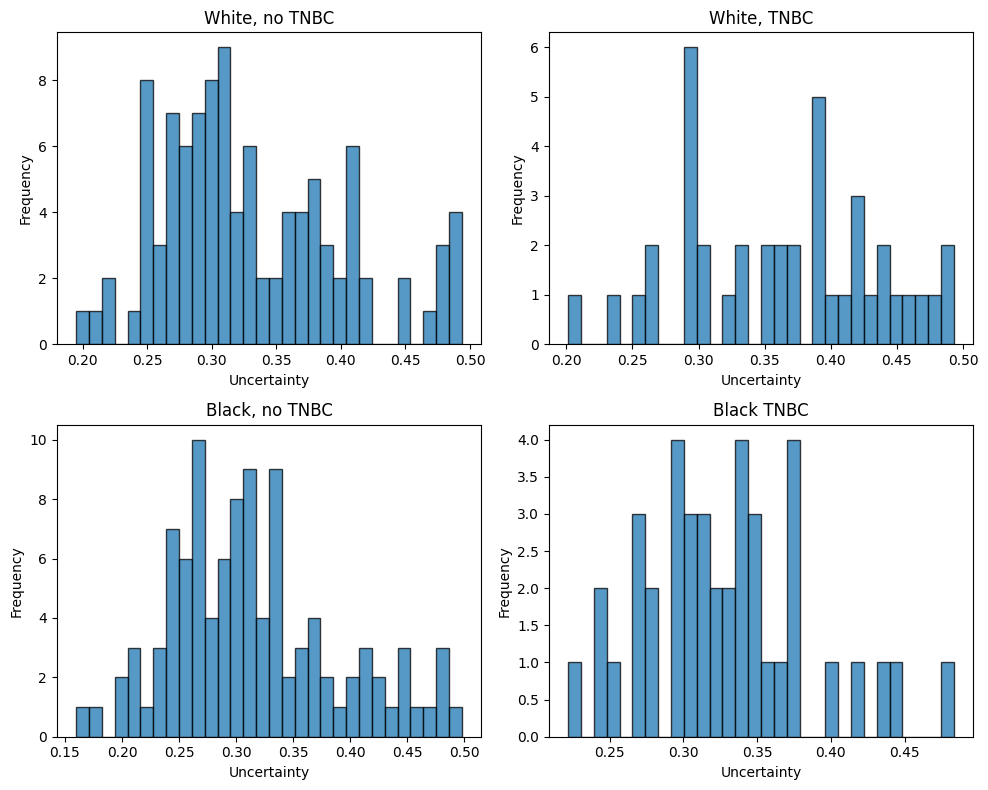

In [20]:
data_sets = [uncertainty00, uncertainty01, uncertainty10, uncertainty11]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()            # easier to iterate over

# ------------------------------------------------------------------
# 3. Draw one histogram per panel                                   |
# ------------------------------------------------------------------
titles = ["White, no TNBC", "White, TNBC", "Black, no TNBC", "Black TNBC"]

for idx, (ax, x) in enumerate(zip(axes, data_sets)):
    ax.hist(x,
            bins=30,
            alpha=0.75,
            edgecolor="black")
    ax.set_title(titles[idx])
    ax.set_xlabel("Uncertainty")
    ax.set_ylabel("Frequency")

# ------------------------------------------------------------------
# 4. Cosmetic tidy-up                                               |
# ------------------------------------------------------------------
plt.tight_layout()               # remove overlapping labels
plt.show()

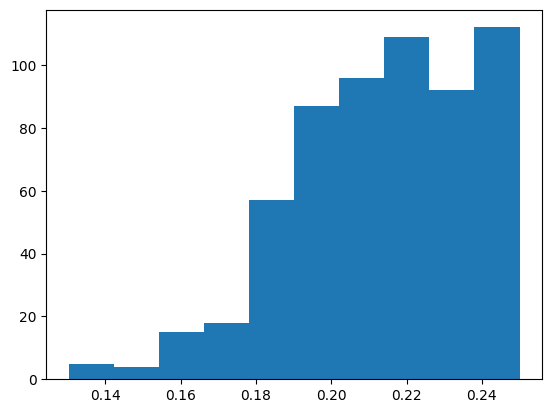

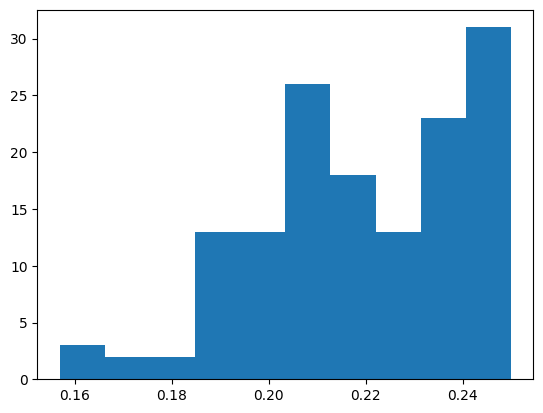

In [8]:
plt.hist(u1)
plt.show()
plt.hist(u0)
plt.show()

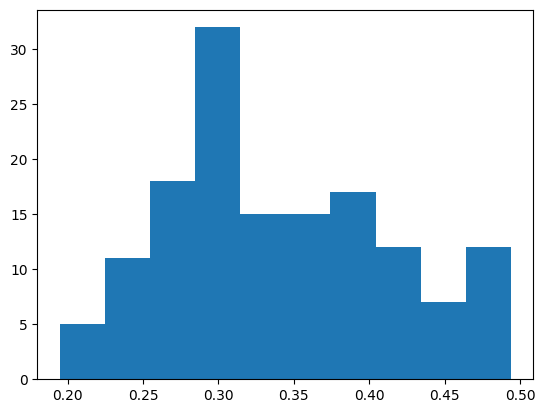

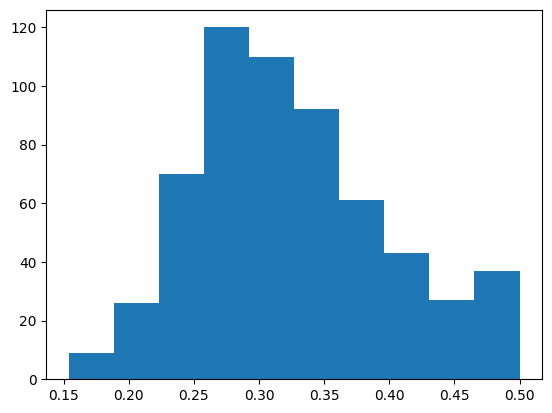

In [12]:
plt.hist(uncertainty0)
plt.show()
plt.hist(uncertainty1)
plt.show()

In [ ]:
np.random.seed(614)
alpha = 0.1 # desired error level for confidence interval
fracs_human = np.linspace(0.2, 0.8, 20) # sampling budget
#fracs_human = [0.2]
num_trials = 500

num_methods = 6

temp_df = pd.DataFrame({
    "lb": np.zeros(num_methods),
    "ub": np.zeros(num_methods),
    "interval width": np.zeros(num_methods),
    "coverage": np.zeros(num_methods),
    "estimator": [""] * num_methods,
    "$n_{\mathrm{human}}$": np.zeros(num_methods),
    "$n_{\mathrm{effective}}$": np.zeros(num_methods)
})

#tau = 1 # mix with uniform if want
tau = 0.1

results = []

frac_human = fracs_human[j]
uncertainty0 = np.minimum(Yhat0, 1-Yhat0)
uncertainty1 = np.minimum(Yhat1, 1-Yhat1) 
lambda1_pilot = np.mean((Y1_train - Y1_train.mean()) * (Yhat1_train - Yhat1_train.mean())) / np.var(f_X1_train)
lambda1_train = opt_mean_tuning(Y1_train, Yhat1_train, weights_spline0, sampling_ratio_spline0)
#u1 = Yhat1 * (1 - Yhat1)
#u0 = Yhat0 * (1 - Yhat0)
c1 = f(X)
c0 = 
for j in tqdm(range(len(fracs_human))):
    eta0 = frac_human / np.mean(uncertainty0)
    eta1 = frac_human / np.mean(uncertainty1)   
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1
    #p0_active = uncertainty0  * frac_human * n  / (n0 * (np.mean(uncertainty0) + np.mean(uncertainty1)))
    #p1_active = uncertainty1 * frac_human * n / (n1 * (np.mean(uncertainty0) + np.mean(uncertainty1)))
    #p0_active = uncertainty0 * (frac_human) /np.mean(np.concatenate([uncertainty0, uncertainty1]))
    #p1_active = uncertainty1 * (frac_human) / np.mean(np.concatenate([uncertainty0, uncertainty1]))
    #p0_active = uncertainty0 / np.sum(uncertainty0) * (frac_human * n) * 1/2
    #p1_active = uncertainty1 / np.sum(uncertainty1) * (frac_human * n) * 1/2
    #print(np.sum(np.concatenate([p0_active, p1_active])))
    p0_active = np.clip((1-tau) * p0_active + tau * frac_human, 0, 1)
    p1_active = np.clip((1 - tau) * p1_active + tau * frac_human, 0, 1)

    # spline
    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1, u0, u1, u0, mu1_train, mu0_train, n * frac_human, num_knots=5, degree=3
    )
    
    #print(np.sum(np.concatenate([p1_spline, p0_spline])))
    
    for i in tqdm(range(num_trials)):
        # active
        weights_active0 = bernoulli.rvs(p0_active) / p0_active
        weights_active1 = bernoulli.rvs(p1_active) / p1_active
        sampling_ratio_active0 = (1 - p0_active) / p0_active
        sampling_ratio_active1 = (1 - p1_active) / p1_active
        lam0_active = opt_mean_tuning(Y0, Yhat0, weights_active0, sampling_ratio_active0)
        lam1_active = opt_mean_tuning(Y1, Yhat1, weights_active1, sampling_ratio_active1)

        #spline
        weights_spline0 = bernoulli.rvs(p0_spline) / p0_spline
        weights_spline1 = bernoulli.rvs(p1_spline) / p1_spline
        sampling_ratio_spline0 = (1 - p0_spline) / p0_spline
        sampling_ratio_spline1 = (1 - p1_spline) / p1_spline
        lam0_spline = opt_mean_tuning(Y0, Yhat0, weights_spline0, sampling_ratio_spline0)
        lam1_spline = opt_mean_tuning(Y1, Yhat1, weights_spline1, sampling_ratio_spline1)
        
        # correlated sampling to ensure that active and spline are comparable
        #l_A, u_A, varhat_A, l_B, u_B, varhat_B = sample_ci(Y0, Yhat0, Y1, Yhat1, p0_active, p1_active, p0_spline, p1_spline, alpha, frac_human, tau, lhat0_A=None, lhat1_A=None, lhat0_B=None, lhat1_B=None)
        # active
        l_A, u_A, varhat_A = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_active0, weights_active1, alpha, lhat0=1, lhat1=1)
        coverage_active = (true_odds_ratio >= l_A)*(true_odds_ratio <= u_A)
        temp_df.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(frac_human*n), (true_var / varhat_A) * n

        l_S, u_S, varhat_S = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_spline0, weights_spline1, alpha, lhat0=1, lhat1=1)
        coverage_spline = (true_odds_ratio >= l_S)*(true_odds_ratio <= u_S)
        temp_df.loc[1] = l_S, u_S, u_S-l_S, coverage_spline, "spline", int(frac_human*n), (true_var / varhat_S) * n

        l_A, u_A, varhat_A = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_active0, weights_active1, alpha, lhat0=lam0_active, lhat1=lam1_active)
        coverage_active = (true_odds_ratio >= l_A)*(true_odds_ratio <= u_A)
        temp_df.loc[2] = l_A, u_A, u_A-l_A, coverage_active, "active + tuning", int(frac_human*n), (true_var / varhat_A) * n

        l_S, u_S, varhat_S = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_spline0, weights_spline1, alpha, lhat0=lam0_spline, lhat1=lam1_spline)
        coverage_spline = (true_odds_ratio >= l_S)*(true_odds_ratio <= u_S)
        temp_df.loc[3] = l_S, u_S, u_S-l_S, coverage_spline, "spline + tuning", int(frac_human*n), (true_var / varhat_S) * n

        xi_unif0 = bernoulli.rvs([frac_human] * n0)
        xi_unif1 = bernoulli.rvs([frac_human] * n1)
        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, xi_unif0/frac_human, xi_unif1/frac_human, alpha, lhat0=1, lhat1=1)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[4] = l, u, u-l, coverage, "uniform", int(n*frac_human), (true_var / varhat)*n
        
        mu0 = Y0[np.where(xi_unif0)].mean()
        mu1 = Y1[np.where(xi_unif1)].mean()
        odds_ratio_est = np.log((mu1 / (1 - mu1)) / (mu0 / (1 - mu0)))
        varhat = (1/np.sum(Y0[np.where(xi_unif0)]==0) + 1/np.sum(Y0[np.where(xi_unif0)]==1) + 1/np.sum(Y1[np.where(xi_unif1)]==0) + 1/np.sum(Y1[np.where(xi_unif1)]==1))
        l = np.exp(odds_ratio_est - norm.ppf(1-alpha/2)*np.sqrt(varhat))
        u = np.exp(odds_ratio_est + norm.ppf(1-alpha/2)*np.sqrt(varhat))
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[5] = l, u, u-l, coverage, "classical", int(n*frac_human), (true_var / varhat)

        # LLM_only_sample0 = np.random.choice(n0, n0, replace=True)
        # LLM_only_sample1 = np.random.choice(n1, n1, replace=True)
        # Yhat0_i = Yhat0[LLM_only_sample0]
        # Yhat1_i = Yhat1[LLM_only_sample1]
        # muhat0 = Yhat0_i.mean()
        # muhat1 = Yhat1_i.mean()
        # odds_ratio_est = (muhat1 / (1 - muhat1)) / (muhat0 / (1 - muhat0))
        # varhat = (1/np.sum(Yhat0_i==0) + 1/np.sum(Yhat0_i==1) + 1/np.sum(Yhat1_i==0) + 1/np.sum(Yhat1_i==1))
        # l = np.exp(odds_ratio_est - norm.ppf(1-alpha/2)*np.sqrt(varhat))
        # u = np.exp(odds_ratio_est + norm.ppf(1-alpha/2)*np.sqrt(varhat))
        # coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        # temp_df.loc[6] = l, u, u-l, coverage, "LLM only", int(n*frac_human), 0

        results += [temp_df.copy()]
df = pd.concat(results, ignore_index = True)
df["coverage"] = df["coverage"].astype(bool)

100%|██████████| 20/20 [00:34<00:00,  1.75s/it]


In [78]:
fracs_human * n

array([147.8       , 172.43333333, 197.06666667, 221.7       ,
       246.33333333, 270.96666667, 295.6       , 320.23333333,
       344.86666667, 369.5       ])

In [107]:
df[df["$n_{\mathrm{human}}$"] == 147.0]

,lb,ub,interval width,coverage,estimator,$n_{\mathrm{human}}$,$n_{\mathrm{effective}}$
0,0.138884,0.761624,0.622741,True,active,147.0,132.063665
1,0.298096,1.177322,0.879226,True,spline,147.0,202.721764
2,0.186130,0.770719,0.584589,True,active + tuning,147.0,189.450126
3,0.268341,1.038276,0.769935,True,spline + tuning,147.0,208.917644
4,0.113934,0.502145,0.388211,True,uniform,147.0,173.847372
...,...,...,...,...,...,...,...
2995,0.376550,1.261347,0.884798,True,spline,147.0,261.721005
2996,0.172048,0.618773,0.446724,True,active + tuning,147.0,233.461270
2997,0.266340,0.966864,0.700524,True,spline + tuning,147.0,230.097736
2998,0.117813,0.620605,0.502792,True,uniform,147.0,138.535197


In [97]:
lam0_active, lam0_active

(0.5539977521287981, 0.5539977521287981)

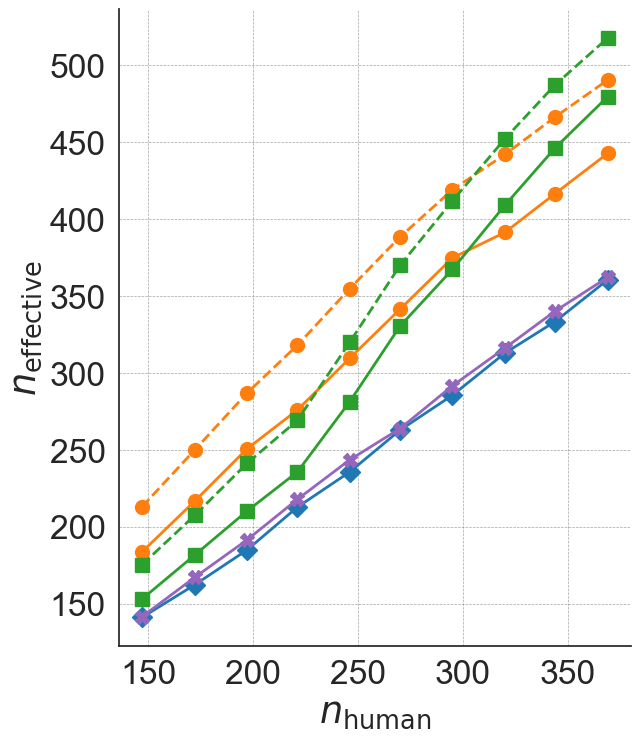

In [130]:
plot_eff_sample_size(df, "plots/BRCA_ESS_evensplit.pdf")

In [68]:
df.to_csv('BRCA_results.csv', index = False)

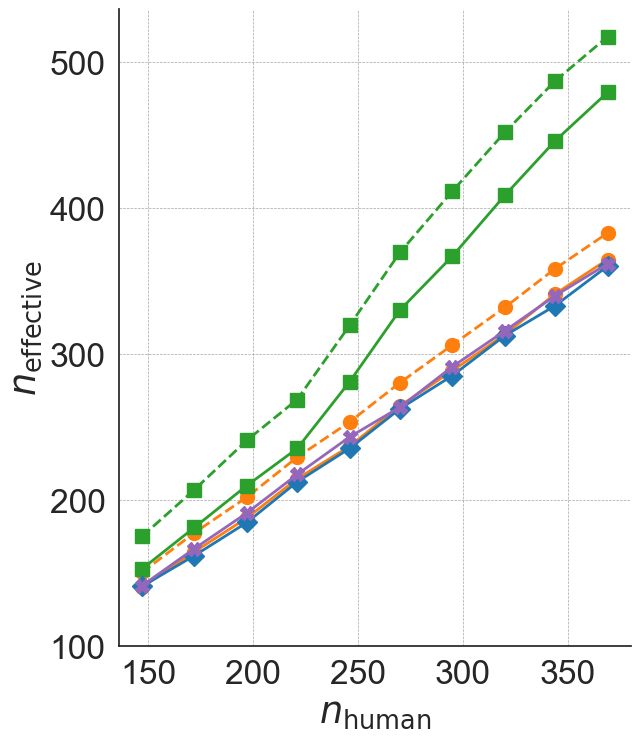

In [57]:
plot_eff_sample_size(df, "plots/BRCA_ESS_new.pdf")

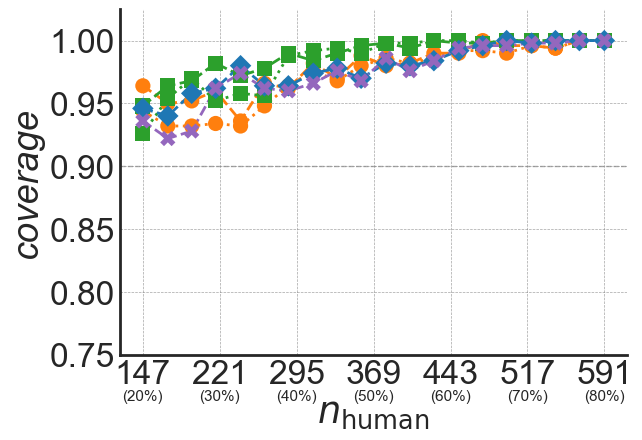

In [182]:
# ────────────────────────────────────
# 1.  keep six estimators of interest
# ────────────────────────────────────
desired_order = ["active", "active + tuning",
                    "spline", "spline + tuning",
                    "uniform", "classical"]
df = df[df.estimator.isin(desired_order)].copy()

# optional: make "LLM only" flat (kept for completeness; remove if unused)
if "LLM only" in df.estimator.unique():
    llm_only_mean = df.loc[df.estimator == "LLM only", "coverage"].mean()
    df.loc[df.estimator == "LLM only", "coverage"] = llm_only_mean

# ────────────────────────────────────
# 2.  aesthetic maps
# ────────────────────────────────────
color_map = {"active":           'tab:orange',
                "active + tuning":  'tab:orange',
                "spline":           'tab:green',
                "spline + tuning":  'tab:green',
                "uniform":          'tab:blue',
                "classical":        'tab:purple'}

linestyle_map = {"active": "--",           # all dashed in screenshot style
                    "active + tuning": ":",
                    "spline": "--",
                    "spline + tuning": ":",
                    "uniform": "--",
                    "classical": "--"}

marker_map = {"active": "o", "active + tuning": "o",
                "spline": "s", "spline + tuning": "s",
                "uniform": "D", "classical": "X"}

# ────────────────────────────────────
# 3.  prepare data (mean over trials)
# ────────────────────────────────────
xlab = r"$n_{\mathrm{human}}$"
ylab = "coverage"

df_mean = (df.groupby([xlab, "estimator"], observed=True)[ylab]
                .mean()
                .reset_index())

# ────────────────────────────────────
# 4.  plot
# ────────────────────────────────────
sns.set_theme(font_scale=2.2,
                style="white",
                rc={"lines.linewidth": 3, "axes.linewidth": 2})

fig, ax = plt.subplots(figsize=(7, 5))

for est in desired_order:
    sub = df_mean[df_mean["estimator"] == est]
    if sub.empty:
        continue

    # dashed trend line
    ax.plot(sub[xlab], sub[ylab],
            label=est,
            color=color_map[est],
            linestyle=linestyle_map[est],
            linewidth=2)

    # filled marker with thin black edge (no white halo)
    ax.scatter(sub[xlab], sub[ylab],
                marker=marker_map[est],
                s=120,                    # marker size
                color=color_map[est],
                edgecolor='none',
                zorder=3)

# nominal line at 1-alpha
ax.axhline(1 - alpha, color="#888888",
            linestyle="--", linewidth=1, alpha=0.7, zorder=1)

# axes, grid, ticks
ax.grid(True, which='both', linestyle='--',
        linewidth=0.5, color='gray', alpha=0.7)
sns.despine(ax=ax, top=True, right=True)

n_vals = np.linspace(0.2, 0.8, 7)
main_ticks = (n_vals * n).astype(int)     # e.g. 147, 221, …

ax.set_xticks(main_ticks)
ax.set_xticklabels([f"{t}" for t in main_ticks])   # big numbers only

# add the percentages as smaller annotations just below each tick
# for x_val, frac in zip(main_ticks, n_vals):
#     ax.annotate(f"({frac:.0%})",
#                 xy=(x_val, 0), xycoords=("data", "axes fraction"),
#                 xytext=(0, -14), textcoords="offset points",
#                 ha="center", va="top",
#                 fontsize=11) 
# plt.subplots_adjust(bottom=0.18)       
# # tick_labels = []

for x, frac in zip(main_ticks, n_vals):
    ax.text(x, -0.1,                      # y = −0.10 of axes height
            f"({frac:.0%})",
            transform=ax.get_xaxis_transform(),  # x in data, y in axes frac
            ha="center", va="top",
            fontsize=11)

ax.set_xlabel(xlab, fontstyle='italic')
ax.set_ylabel(ylab, fontstyle='italic')
ax.set_ylim(0.75, 1.025)
ax.set_yticks(np.linspace(0.75, 1, 6))
ax.tick_params(axis='both', direction='in', width=2, length=6)

# no legend box (comment out to show)
if ax.get_legend():
    ax.legend().remove()

plt.tight_layout()
plt.savefig("plots/BRCA_coverage_mod.pdf", bbox_inches='tight', dpi=300)
plt.show()

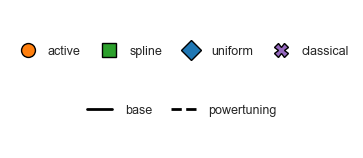

In [196]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── build legend handles in plotting order ───────────────────────────
handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="tab:orange",
           markersize=10, label="active"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="tab:green",
           markersize=10, label="spline"),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="tab:blue",
           markersize=10, label="uniform"),
    Line2D([0], [0], marker="X", color="none", markerfacecolor="tab:purple",
           markersize=10, label="classical")
]

line_handles = [
    Line2D([], [], color="black", linewidth=2, linestyle="-",
           label="base"),
    Line2D([], [], color="black", linewidth=2, linestyle="--",
           label="powertuning"),
]

# ── empty canvas (4 in × 1.8 in is plenty) ──────────────────────────
fig, ax = plt.subplots(figsize=(4, 1.8))
ax.axis('off')

# Row 1: coloured markers
first_row = ax.legend(handles=handles,
                      loc="center", bbox_to_anchor=(0.5, 0.70),
                      ncol=4, frameon=False,
                      columnspacing=1.3, handletextpad=0.6,
                      fontsize=9)
ax.add_artist(first_row)   # keep it when adding second legend

# Row 2: line styles
ax.legend(handles=line_handles,
          loc="center", bbox_to_anchor=(0.5, 0.27),
          ncol=2, frameon=False,
          columnspacing=1.5, handletextpad=1.0,
          fontsize=9)
plt.savefig("legend_left_2row.pdf", bbox_inches="tight")
plt.show()

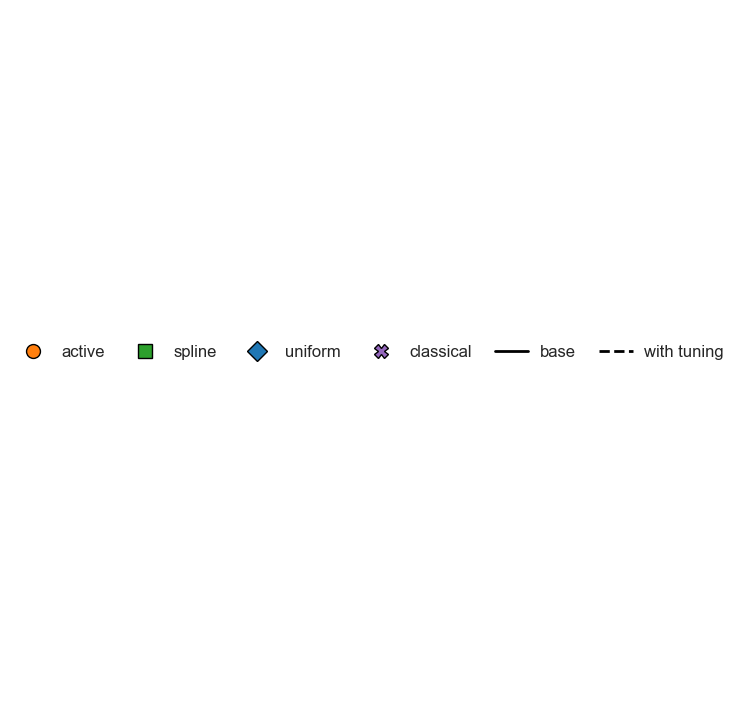

In [191]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── build legend handles in plotting order ───────────────────────────
handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="tab:orange",
           markersize=10, label="active"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="tab:green",
           markersize=10, label="spline"),
    Line2D([0], [0], marker="D", color="none", markerfacecolor="tab:blue",
           markersize=10, label="uniform"),
    Line2D([0], [0], marker="X", color="none", markerfacecolor="tab:purple",
           markersize=10, label="classical"),
    Line2D([0], [0], color="black", linewidth=2, linestyle="-",
           label="base"),
    Line2D([0], [0], color="black", linewidth=2, linestyle="--",
           label="with tuning"),
]

# ── blank figure ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 9))
ax.axis("off")                       # nothing but the legend

# ── single‑row legend centred near the middle ────────────────────────
fig.legend(handles=handles,
           loc="center", bbox_to_anchor=(0.5, 0.5),   # centred
           ncol=6, frameon=False,
           columnspacing=1.4, handletextpad=0.7,
           fontsize=12)

plt.savefig("legend_one_row.pdf", bbox_inches="tight")
plt.show()


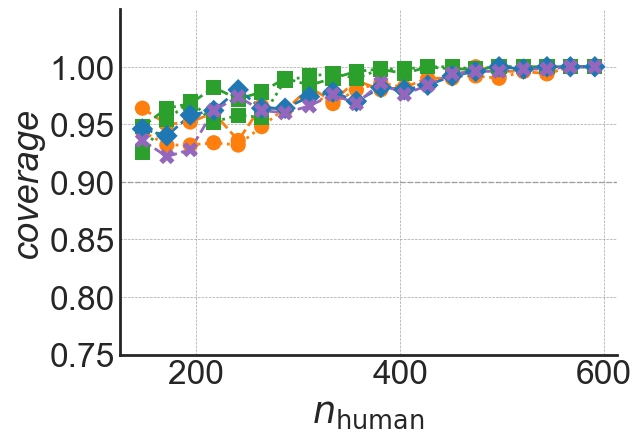

In [178]:
plot_coverage(df, alpha, "plots/BRCA_coverage_new.pdf")

In [19]:
def plot_intervals(
    df,
    true_val,
    num_trials,
    estimand_title,
    plot_title,
    n_ind=-1,
    num_ints=5
):
    """
    Show `num_ints` random confidence intervals from six estimators at one
    chosen n_human slice, using four colours and distinct linestyles.

    Parameters
    ----------
    df : DataFrame with columns
         * '$n_{\\mathrm{human}}$'
         * 'estimator'
         * 'lb', 'ub'
    true_val : float   (vertical reference line)
    num_trials : int   (number of rows per estimator per n_human)
    estimand_title : str (x-axis label)
    plot_title : str   (file path to save figure)
    n_ind : int        (which n_human index to visualise; -1 = largest)
    num_ints : int     (how many intervals to draw per estimator)
    """

    # ── 1. method order & aesthetic maps -----------------------------------
    methods = ["active", "active + tuning",
               "spline", "spline + tuning",
               "uniform", "classical"]

    colour = {"active":          'tab:orange',
              "active + tuning": 'tab:orange',
              "spline":          'tab:green',
              "spline + tuning": 'tab:green',
              "uniform":         'tab:blue',
              "classical":       'tab:purple'}

    filled = {}

    linestyle = {
        "active": "-",
        "active + tuning": "-",
        "spline": "-",
        "spline + tuning": "-",
        "uniform": "-",
        "classical": "-",
    }

    # ── 2. choose which n_human to show & which trial rows -----------------
    ns        = np.sort(df["$n_{\\mathrm{human}}$"].unique())
    n_example = ns[n_ind]                         # pick the slice
    rng_rows  = np.random.choice(num_trials, num_ints, replace=False)

    # pre-compute the intervals we’ll draw
    ints = {m: [] for m in methods}
    for m in methods:
        rows = df[(df.estimator == m) &
                  (df["$n_{\\mathrm{human}}$"] == n_example)].iloc[rng_rows]
        for _, row in rows.iterrows():
            ints[m].append((row.lb, row.ub))

    # ── 3. vertical placement ---------------------------------------------
    gap          = 0.03           # between intervals inside a band
    band_spacing = 0.15           # space between estimator bands
    top_start    = 0.85
    y_base = {m: top_start - i * band_spacing for i, m in enumerate(methods)}

    # ── 4. plotting --------------------------------------------------------
    sns.set_theme(font_scale=2.2, style='white',
                  rc={'lines.linewidth': 3, 'axes.linewidth': 2})
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.axvline(true_val, color='gray', linestyle='--', linewidth=1)

    # how thick the interval looks
    lw_inner  = 8
    lw_outer  = 9
    rim_const = 0.5               # amount of lightening for fill

    for m in methods:
        base_y = y_base[m]
        for k, (lo, hi) in enumerate(ints[m]):
            y   = base_y + k * gap
            col = colour[m]

            # coloured inner bar with black outline on both sides
            ax.plot([lo, hi], [y, y],
                    color=lighten_color(col, rim_const),
                    linestyle=linestyle[m],
                    linewidth=lw_inner,
                    path_effects=[
                        pe.Stroke(linewidth=lw_outer,
                                  foreground='black'),
                        pe.Normal()
                    ],
                    solid_capstyle='butt')

    # aesthetics -----------------------------------------------------------
    ax.set_xlabel(estimand_title, fontstyle='italic')
    ax.set_yticks([])
    sns.despine(ax=ax, top=True, right=True, left=True)

    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()

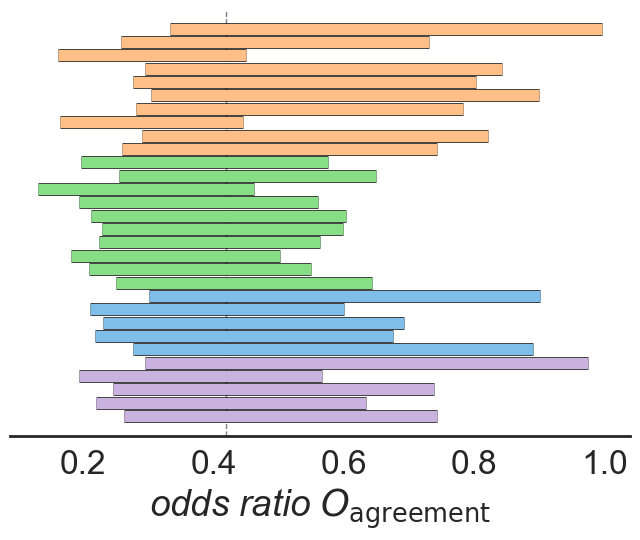

In [28]:
plot_intervals(df, true_odds_ratio, num_trials, "odds ratio $O_{\mathrm{agreement}}$", "plots/stance_intervals_test.pdf", n_ind=7)

In [29]:
import matplotlib.patches as mpatches

In [48]:
def plot_intervals(
    df,
    true_val,
    num_trials,
    estimand_title,
    plot_title,
    n_ind=-1,
    num_ints=5,
):
    # ── 1.      define estimator order & style maps ------------------------
    methods = ["active", "active + tuning",
               "spline", "spline + tuning",
               "uniform", "classical"]

    base_colour = {"active":          "#F29F5B",   # orange
                   "active + tuning": "#F29F5B",
                   "spline":          "#6EAD61",   # green
                   "spline + tuning": "#6EAD61",
                   "uniform":         "#5D8DB9",   # blue
                   "classical":       "#9B59B6"}   # purple

    hatch = {"active": "",
             "active + tuning": "///",
             "spline": "",
             "spline + tuning": "///",
             "uniform": "",
             "classical": ""}

    # lighten every fill by this fraction (0 = original, 1 = white)
    lighten_const = 0.35

    # ── 2.      pick one n_human slice & sample rows ----------------------
    ns        = np.sort(df["$n_{\\mathrm{human}}$"].unique())
    n_slice   = ns[n_ind]
    rows_idx  = np.random.choice(num_trials, num_ints, replace=False)

    # grab intervals for that slice
    intervals = {m: [] for m in methods}
    for m in methods:
        rows = df[(df.estimator == m) &
                  (df["$n_{\\mathrm{human}}$"] == n_slice)].iloc[rows_idx]
        for _, r in rows.iterrows():
            intervals[m].append((r.lb, r.ub))

    # ── 3.      layout parameters (tuned to remove crowding) --------------
    band_height  = 0.05    # thinner bars
    gap_inside   = 0.04    # gap inside each estimator band
    band_space   = 0.22    # vertical space between estimator bands
    top_y        = 0.94    # start near the top

    y_base = {m: top_y - i * band_space for i, m in enumerate(methods)}

    # ── 4.      plot -------------------------------------------------------
    sns.set_theme(font_scale=2.1, style='white',
                  rc={'axes.linewidth': 2})

    fig, ax = plt.subplots(figsize=(7, 10))

    # vertical reference
    ax.axvline(true_val, color='gray', linestyle='--', linewidth=1)

    for m in methods:
        y0 = y_base[m]
        for k, (lo, hi) in enumerate(intervals[m]):
            rect = mpatches.Rectangle(
                (lo, y0 + k * gap_inside),  # (x,y)
                hi - lo,                    # width
                band_height,                # height
                facecolor=lighten_color(base_colour[m], lighten_const),
                edgecolor='black',
                linewidth=1.0,
                hatch=hatch[m],
                zorder=3
            )
            ax.add_patch(rect)

    # ── 5.      cosmetics ---------------------------------------------------
    ax.set_xlabel(estimand_title, fontstyle='italic')
    ax.set_yticks([])
    #ax.set_xlim(df[["lb","ub"]].min().min(), df[["lb","ub"]].max().max())
    sns.despine(ax=ax, top=True, right=True, left=True)

    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()

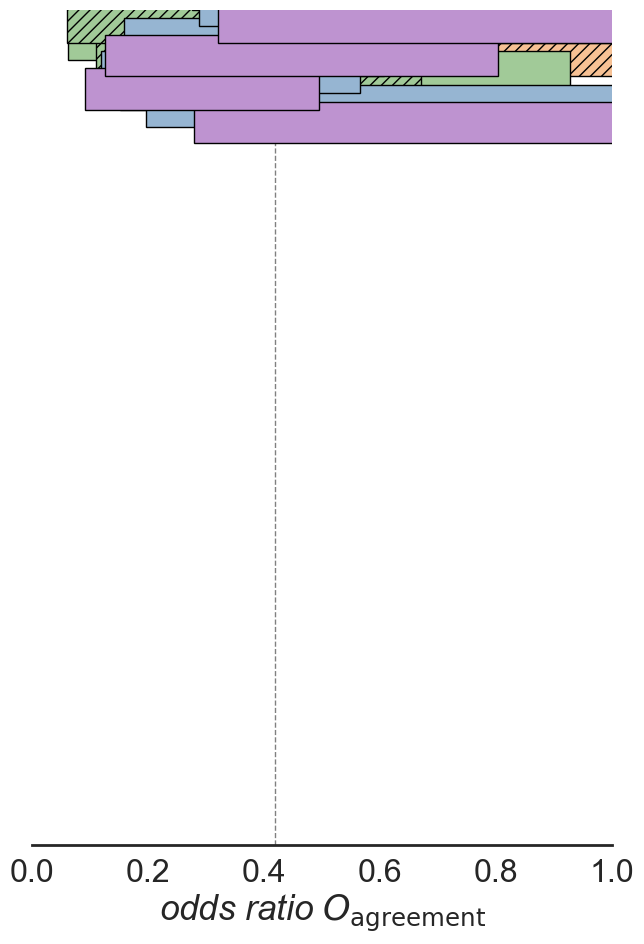

In [49]:
plot_intervals(df, true_odds_ratio, num_trials, "odds ratio $O_{\mathrm{agreement}}$", "plots/stance_intervals_fancy.pdf", n_ind=0, num_ints=4)

In [176]:
def plot_intervals(
        df,
        true_val,
        num_trials,
        estimand_title,
        plot_title,
        n_ind=-1,          # which n_human slice (−1 == last / largest)
        num_ints=5,        # intervals per estimator to show
        bar_height=0.2,    # in y–grid units (≤1.0)
        inner_gap = 0,
        gap=0            # vertical gap between colour groups
):
    # ─── 1. estimator order & style maps ─────────────────────────────────
    methods = ["active", "active + tuning",
               "spline", "spline + tuning",
               "uniform", "classical"]

    colours = {"active":           "#F29F5B",   # orange
               "active + tuning":  "#F29F5B",
               "spline":           "#6EAD61",   # green
               "spline + tuning":  "#6EAD61",
               "uniform":          "#5D8DB9",   # blue
               "classical":        "#9B59B6"}   # purple

    hatches = {"active": "",
               "active + tuning": "///",
               "spline": "",
               "spline + tuning": "///",
               "uniform": "",
               "classical": ""}

    # ─── 2. choose n_human slice & sample rows ───────────────────────────
    ns = np.sort(df["$n_{\\mathrm{human}}$"].unique())
    n_human = ns[n_ind]

    # randomly choose the row positions once, reuse across estimators
    rng_rows  = np.random.choice(num_trials, num_ints, replace=False)

    # build a list of (estimator, lo, hi) in desired plotting order
    rows_to_plot = []
    for est in methods:
        subset = df[(df.estimator == est) & (df["$n_{\\mathrm{human}}$"] == n_human)]
        if len(subset) == 0:
            continue                     # skip if estimator absent
        subset = subset.iloc[rng_rows % len(subset)]  # safe wrap
        for _, r in subset.iterrows():
            rows_to_plot.append((est, r.lb, r.ub))

    # reverse so first interval appears at top
    rows_to_plot = rows_to_plot[::-1]

    # ─── 3. figure size: 0.45″ per interval row works well ───────────────
    stride = bar_height + inner_gap          # e.g. 0.35 + 0.05 = 0.40
    fig_h = max(4, stride * len(rows_to_plot))
    #fig_h = max(4, 0.45 * len(rows_to_plot))
    sns.set_theme(font_scale=2.2, style='white', rc={'axes.linewidth': 2})
    fig, ax = plt.subplots(figsize=(7, fig_h))

    # vertical reference
    ax.axvline(true_val, color='gray', linestyle='--', linewidth=1)

    # ─── 4. add rectangles, one y–unit per interval ──────────────────────
    for y, (est, lo, hi) in enumerate(rows_to_plot):
        rect = mpatches.Rectangle(
            (lo, y - bar_height/2),          # (x-left, y-bottom)
            hi - lo,                         # width
            bar_height,                      # height
            facecolor=lighten_color(colours[est], 0.35),
            edgecolor='black',
            linewidth=1,
            hatch=hatches[est],
            zorder=3
        )
        ax.add_patch(rect)

    # ─── 5. tidy up axes ─────────────────────────────────────────────────
    #ymax = len(rows_to_plot) - 0.5
    #ymin = -0.5
    #ax.set_ylim(ymax + gap, ymin)           # invert y so first row at top
    #ax.set_yticks([])
    ymax = (len(rows_to_plot) - 1) * stride + bar_height / 2
    ax.set_ylim(ymax + gap, -bar_height / 2)   # top‑extra gap
    ax.set_yticks([])

    # x-limits: add 5 % padding either side
    #xmin = df[["lb", "ub"]].min().min()
    #xmax = df[["lb", "ub"]].max().max()
    #pad  = 0.05 * (xmax - xmin)
    #ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_xlabel(estimand_title, fontstyle='italic')
    sns.despine(ax=ax, top=True, right=True, left=True)
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()


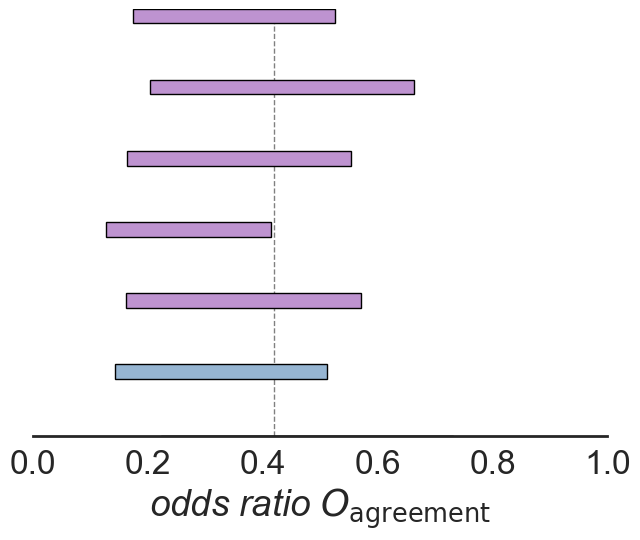

In [177]:
plot_intervals(df, true_odds_ratio, num_trials, "odds ratio $O_{\mathrm{agreement}}$", "plots/BRCA_intervals_modbars.pdf", n_ind=5)

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from matplotlib.colors import to_rgb

def lighten_color(c, amount=0.35):
    c = np.array(to_rgb(c))
    return tuple((1 - amount) * c + amount)

def plot_intervals_safe(
    df,
    true_val,
    num_trials,
    estimand_title,
    plot_title,
    n_ind=-1,
    num_ints=5,
    methods=None,           # pass your list here if different
    lb_col="lb",
    ub_col="ub",
):
    # ── 0.  estimator list --------------------------------------------------
    if methods is None:
        methods = ["active", "active + tuning",
                   "spline", "spline + tuning",
                   "uniform", "classical"]

    present = df.estimator.unique()
    missing = [m for m in methods if m not in present]
    if missing:
        print("[WARN] missing estimators:", missing)
        methods = [m for m in methods if m in present]
        if not methods:
            raise ValueError("None of the requested estimators are in df.")

    print("[INFO] plotting methods:", methods)

    # ── 1.  style maps ------------------------------------------------------
    base_colour = {"active":          "#F29F5B",
                   "active + tuning": "#F29F5B",
                   "spline":          "#6EAD61",
                   "spline + tuning": "#6EAD61",
                   "uniform":         "#5D8DB9",
                   "classical":       "#9B59B6"}

    hatch = {"active": "",
             "active + tuning": "///",
             "spline": "",
             "spline + tuning": "///",
             "uniform": "",
             "classical": ""}

    # ── 2.  pick n_human slice & sample rows -------------------------------
    ns = np.sort(df["$n_{\\mathrm{human}}$"].unique())
    if n_ind >= len(ns):
        raise IndexError(f"n_ind={n_ind} exceeds available n_human slices.")
    n_slice = ns[n_ind]

    rows_idx = np.random.choice(min(num_trials, len(df)), num_ints, replace=False)

    intervals = {m: [] for m in methods}
    for m in methods:
        rows = df[(df.estimator == m) &
                  (df["$n_{\\mathrm{human}}$"] == n_slice)]
        if len(rows) == 0:
            continue
        rows = rows.iloc[rows_idx % len(rows)]   # safe modulo wrap
        for _, r in rows.iterrows():
            intervals[m].append((r[lb_col], r[ub_col]))

    # ── 3.  layout ----------------------------------------------------------
    band_h      = 0.05
    gap_in      = 0.04
    band_space  = 0.22
    top_y       = 0.94
    y_base = {m: top_y - i * band_space for i, m in enumerate(methods)}

    # ── 4.  plot ------------------------------------------------------------
    sns.set_theme(font_scale=2.1, style='white', rc={'axes.linewidth': 2})
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.axvline(true_val, color='gray', linestyle='--', linewidth=1)

    for m in methods:
        y0 = y_base[m]
        for k, (lo, hi) in enumerate(intervals[m]):
            rect = mpatches.Rectangle(
                (lo, y0 + k * gap_in),
                hi - lo,
                band_h,
                facecolor=lighten_color(base_colour[m], 0.35),
                edgecolor='black',
                linewidth=1,
                hatch=hatch[m],
                zorder=3
            )
            ax.add_patch(rect)

    # auto-scale x if lb/ub exist
    if lb_col in df.columns and ub_col in df.columns:
        ax.set_xlim(df[[lb_col, ub_col]].min().min(),
                    df[[lb_col, ub_col]].max().max())

    ax.set_xlabel(estimand_title, fontstyle='italic')
    ax.set_yticks([])
    sns.despine(ax=ax, top=True, right=True, left=True)
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()
""

''

[INFO] plotting methods: ['active', 'active + tuning', 'spline', 'spline + tuning', 'uniform', 'classical']


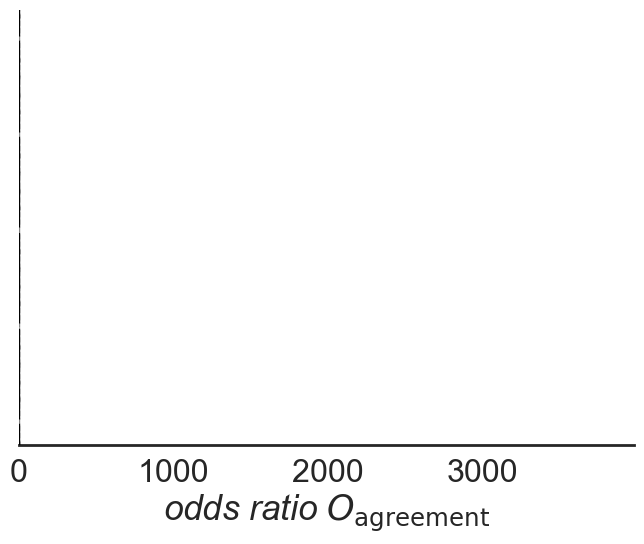

In [33]:
plot_intervals_safe(
    df,
    true_val=true_odds_ratio,
    num_trials=num_trials,           # max rows per estimator per n_human slice
    estimand_title=r"odds ratio $O_{\mathrm{agreement}}$",
    plot_title="plots/intervals_striped.png",
    n_ind=7,                 # last n_human
    num_ints=5                # how many intervals per estimator
)


In [ ]:
def plot_intervals(df, true_val, num_trials, estimand_title, plot_title, n_ind=-1):
    num_ints = 5
    theta_true = true_val
    inds = np.random.choice(num_trials, num_ints)
    ns = df["$n_{\mathrm{human}}$"].unique()
    desired_order = ["confidence-driven", "human + LLM (non-adaptive)", "human only", "LLM only"]
    col = ['tab:orange', "tab:green", "tab:blue", "tab:red"]
    n_example = ns[n_ind]
    ints = [ [] for _ in range(len(desired_order)) ]
    for i in range(len(desired_order)):
        for j in range(num_ints):
            ind = inds[j]
            ints[i].append([df[(df.estimator == desired_order[i]) & (df["$n_{\mathrm{human}}$"] == n_example)].iloc[ind].lb, df[(df.estimator == desired_order[i]) & (df["$n_{\mathrm{human}}$"] == n_example)].iloc[ind].ub])
    gap = 0.03
    start = [0.5, 0.35, 0.2, 0.05]
    linewidth_inner = 8
    linewidth_outer = 9
    lighten_const = 0.5
    foreground_col = "black"
    sns.set_theme(font_scale=2.2, style='white', palette=col, rc={'lines.linewidth': 3})
    fig, ax = plt.subplots()
    ax.axvline(true_val, color='gray', linestyle='dashed')
    for i in reversed(range(num_ints)):
        for j in range(len(desired_order)):
            ax.plot([ints[j][i][0] , ints[j][i][1] ],[start[j]+i*gap,start[j]+i*gap], linewidth=linewidth_inner, color=lighten_color(col[j],lighten_const), path_effects=[pe.Stroke(linewidth=linewidth_outer, offset=(-1,0), foreground=foreground_col), pe.Stroke(linewidth=linewidth_outer, offset=(1,0), foreground=foreground_col), pe.Normal()],  solid_capstyle='butt')
    ax.set_xlabel(estimand_title, fontsize=22)
    ax.set_yticks([])
    sns.despine(top=True, right=True, left=True)
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()

In [ ]:
df

,lb,ub,interval width,coverage,estimator,$n_{\mathrm{human}}$,$n_{\mathrm{effective}}$
0,0.278600,1.560526,1.281926,True,active,147.0,128.836351
1,0.215888,0.999038,0.783151,True,spline,147.0,162.956369
2,0.338229,1.820423,1.482194,True,active + tuning,147.0,135.017042
3,0.205305,0.910721,0.705416,True,spline + tuning,147.0,172.340864
4,0.095956,0.655964,0.560009,True,uniform,147.0,103.514767
...,...,...,...,...,...,...,...
119995,0.268366,0.648906,0.380541,True,spline,369.0,490.623202
119996,0.268871,0.716680,0.447809,True,active + tuning,369.0,397.926833
119997,0.259174,0.612296,0.353122,True,spline + tuning,369.0,517.484761
119998,0.259300,0.706629,0.447328,True,uniform,369.0,380.560865


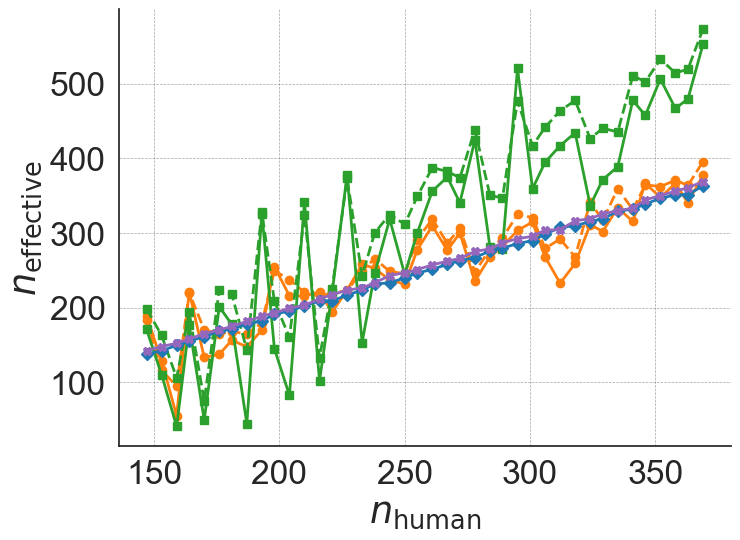

In [115]:
plot_eff_sample_size(df, "plots/BRCA_ESS.pdf")

In [82]:
df

,lb,ub,interval width,coverage,estimator,$n_{\mathrm{human}}$,$n_{\mathrm{effective}}$
0,0.278600,1.560526,1.281926,True,active,147.0,128.836351
1,0.215888,0.999038,0.783151,True,spline,147.0,162.956369
2,0.338229,1.820423,1.482194,True,active + tuning,147.0,135.017042
3,0.205305,0.910721,0.705416,True,spline + tuning,147.0,172.340864
4,0.095956,0.655964,0.560009,True,uniform,147.0,103.514767
...,...,...,...,...,...,...,...
119995,0.268366,0.648906,0.380541,True,spline,369.0,490.623202
119996,0.268871,0.716680,0.447809,True,active + tuning,369.0,397.926833
119997,0.259174,0.612296,0.353122,True,spline + tuning,369.0,517.484761
119998,0.259300,0.706629,0.447328,True,uniform,369.0,380.560865


In [95]:
naive_df

,lb,ub,interval width,coverage,$n_{\mathrm{effective}}$
$n_{\mathrm{human}}$,,,,,
147.0,0.0,inf,inf,1.0,0.0
153.0,0.0,inf,inf,1.0,0.0
159.0,0.0,inf,inf,1.0,0.0
164.0,0.0,inf,inf,1.0,0.0
170.0,0.0,inf,inf,1.0,0.0
176.0,0.0,inf,inf,1.0,0.0
181.0,0.0,inf,inf,1.0,0.0
187.0,0.0,inf,inf,1.0,0.0
193.0,0.0,inf,inf,1.0,0.0


In [94]:
df['coverage'] = df['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_{\mathrm{effective}}$', '$n_{\mathrm{human}}$']
active_df = df[(df["estimator"] == "active")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
varmin_df = df[(df["estimator"] == "spline")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
uniform_df = df[(df["estimator"] == "uniform")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
activetune_df = df[(df["estimator"] == "active + tuning")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
varmintune_df = df[(df["estimator"] == "spline + tuning")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
classical_df = df[(df["estimator"] == "classical")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
naive_df = df[(df["estimator"] == "LLM only")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()

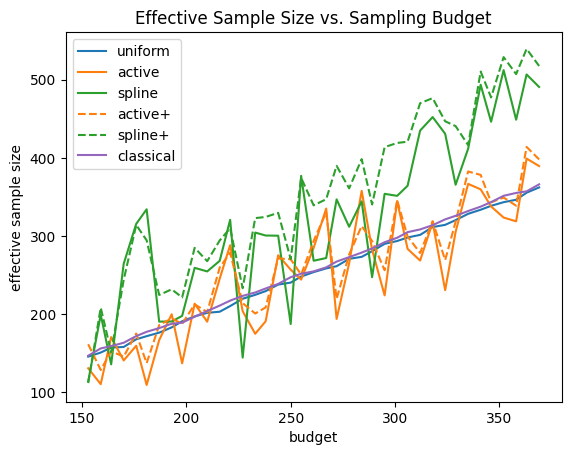

In [84]:
color_map = {
    "uniform": "tab:blue",
    "active": "tab:orange",
    "spline": "tab:green",
    "classical": "tab:purple"
}

# Define linetypes for variations
linestyle_map = {
    "lambda = 0": "solid",
    "power tuning": "dashed"
}

# Plotting each line with appropriate color and linestyle
plt.plot(uniform_df.index[1:], np.array(uniform_df["$n_{\mathrm{effective}}$"])[1:], 
         label="uniform", color=color_map["uniform"], linestyle=linestyle_map["lambda = 0"])

plt.plot(active_df.index[1:], np.array(active_df["$n_{\mathrm{effective}}$"])[1:], 
         label="active", color=color_map["active"], linestyle=linestyle_map["lambda = 0"])

plt.plot(varmin_df.index[1:], np.array(varmin_df["$n_{\mathrm{effective}}$"])[1:], 
         label="spline", color=color_map["spline"], linestyle=linestyle_map["lambda = 0"])

plt.plot(activetune_df.index[1:], np.array(activetune_df["$n_{\mathrm{effective}}$"])[1:], 
         label="active+", color=color_map["active"], linestyle=linestyle_map["power tuning"])

plt.plot(varmintune_df.index[1:], np.array(varmintune_df["$n_{\mathrm{effective}}$"])[1:], 
         label="spline+", color=color_map["spline"], linestyle=linestyle_map["power tuning"])

plt.plot(classical_df.index[1:], np.array(classical_df["$n_{\mathrm{effective}}$"])[1:], 
         label="classical", color=color_map["classical"], linestyle=linestyle_map["lambda = 0"])

# Final plot setup
plt.xlabel("budget")
plt.ylabel("effective sample size")
plt.legend()
plt.title("Effective Sample Size vs. Sampling Budget")
plt.show()

ValueError: The `markers` argument has the wrong number of values

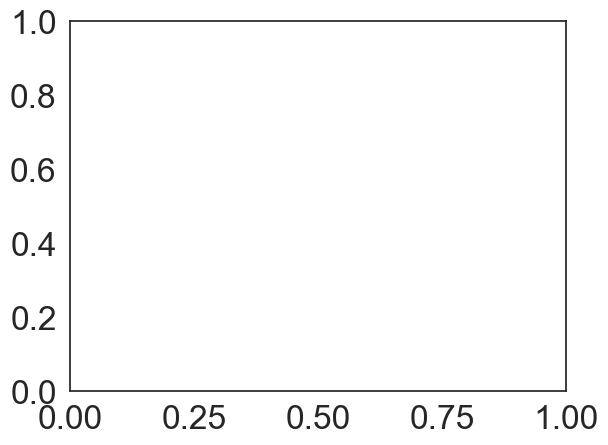

In [96]:
plot_eff_sample_size(df, "plots/BRCA_ESS.pdf")

In [85]:
varmin_df

,lb,ub,interval width,coverage,$n_{\mathrm{effective}}$
$n_{\mathrm{human}}$,,,,,
147.0,0.215888,0.999038,0.783151,1.0,162.956369
153.0,0.097898,0.611174,0.513277,1.0,114.029089
159.0,0.251863,1.007101,0.755238,1.0,199.120689
164.0,0.113374,0.607532,0.494158,1.0,135.724023
170.0,0.273361,0.910155,0.636794,1.0,264.366841
176.0,0.400557,1.204694,0.804137,1.0,315.454043
181.0,0.373844,1.089799,0.715954,1.0,334.129989
187.0,0.182441,0.752772,0.570331,1.0,190.398545
193.0,0.223369,0.921039,0.697670,1.0,190.575812
